<a href="https://colab.research.google.com/github/ksshah/seed-and-scale/blob/main/summary/WiD_Summary_TheWaterBill_Combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Water Bill - Rice x Water-Stress Summary

*Women in Data "What's Cooking?" Datathon, Sept 2026. This notebook ports the pipeline shape from
an earlier internal water-risk simulator onto rice production and trade data.*

**The deliverable.** For a rice-importing country, how exposed is its supply to water stress in the
countries it buys from, and what happens to that supply if a stressed supplier's exports drop? This
notebook builds the four pieces the project's problem statement named "The Water Bill":

1. **Water exposure** - what share of a country's rice imports come from water-stressed exporters.
2. **Supplier concentration** - how many suppliers an importer actually relies on (HHI).
3. **Shock result** - what a production cut at a stressed supplier does to an importer's supply.
4. **Alternative suppliers** - who else could fill the gap, ranked by spare capacity and water headroom.

**Data sources and vintage** (all FAOSTAT bulk downloads, refreshed each run): QCL (Production, Crops and
Livestock Products), TCL (Trade, Crops and Livestock Products), the Detailed Trade Matrix (bilateral
reporter/partner trade), and SDGB (SDG Indicators, series 6.4.2 - freshwater withdrawal as % of available
resources). Production and trade figures cover 2000-2024; water-stress figures are each country's most
recent reported year, which varies by country (see the credibility-check section below).

**Note:** this notebook was authored and reviewed in an environment where FAOSTAT's bulk-download
domain is blocked by network policy, so every cell should be run top-to-bottom in a single `Run All`
pass to generate fresh, consistent outputs before this notebook is treated as final.


## Section 0: Setup

In [58]:
# Section 0: Setup
%pip install -q kaleido
import urllib.request, zipfile, io, os, json, textwrap
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


In [2]:
# Everything this notebook saves (charts + tables) goes into one outputs/ folder, so a
# single download after Run All brings back everything worth keeping alongside this notebook.
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [3]:
# Section 0: Data principles, encoded as config so every downstream calc references the same
# assumptions instead of re-deciding them inline.
# Config values below are carried over verbatim from the underlying rice and water-stress
# pipelines this notebook builds on, so every downstream calc references the same assumptions.
CONFIG = {
    # --- Production (QCL) ---
    'crop_item_code': 27,          # Rice, paddy (QCL) -- production is NOT double-counted with
                                    # milled forms (see the conversion-code notes below)
    'crop_name': 'Rice',

    # --- Trade (TCL / TM) ---
    # Rice production (QCL code 27, paddy basis) is not what crosses borders -- trade is reported in
    # milled forms, so exports need converting back to a paddy-equivalent basis before comparing to
    # production. See the FAO conversion-factor PDF
    # (page 723): https://openknowledge.fao.org/server/api/core/bitstreams/63b8626c-7019-4f8c-a961-e975e7f9e285/content
    'trade_crop_item_code_rm': 31,       # milled/white rice -> paddy-equivalent
    'trade_crop_name_rm': 'Rice; milled',
    'rm_paddy_factor': 0.67,
    'trade_crop_item_code_rmh': 28,      # husked/brown rice -> paddy-equivalent
    'trade_crop_name_rmh': 'Husked rice',
    'rmh_paddy_factor': 0.77,
    # Do NOT add codes 29 (child of 28), 32 (child of 31), or 30 (FAO's own milled-equivalent
    # accumulator, wrong basis for a direct add to 27).

    # --- Area/country cleanup ---
    'aggregate_code_cutoff': 5000,       # FAOSTAT regional/continental aggregates are >= 5000
    'exclude_area_codes': [351, 357, 214, 96, 128],   # China variants -- keep mainland (41) only

    # --- Reporter shortlisting (Section 2) ---
    'reexport_threshold_pct': 130,       # export share of production above this = re-exporter, not a
                                          # genuine source (see Section 2)
    'shortlist_min_export_t': 1_000_000, # minimum paddy-eq tonnes exported to be considered a
                                          # meaningful reporter for the Trade Matrix pull
    'shortlist_min_export_ratio_pct': 5, # minimum export-share-of-production to count as
                                          # export-oriented (arbitrary threshold, flagged for revisit)

    # --- Water stress (SDG 6.4.2: freshwater withdrawal as % of available freshwater resources) ---
    # Tightened from [0,25,50,75,100,inf]: 'No stress'+'Low stress' must exactly match
    # is_stressed (>=25%, below) or the Backup Gap section's candidate pool could let an
    # already-stressed country in as a 'safe' backup source (see the Backup Gap section below).
    'water_stress_bins':   [0, 10, 25, 50, 75, float('inf')],
    'water_stress_labels': ['No stress', 'Low stress', 'Medium stress', 'High stress', 'Critical'],
    'stress_threshold_pct': 25,          # UN-Water's own threshold for entering water stress at all

    # --- Shock simulator (Section: Shock Result) ---
    # Elasticity-1 assumption: a pct_reduction cut in a supplier's production is modeled as the same
    # pct cut in what they export to a given importer. No substitution effects, no price response.
    # Diversification assumes unconstrained headroom at alternative suppliers. Both restated in the
    # Limitations section at the end of this notebook.
}
print(json.dumps({k: v for k, v in CONFIG.items() if k != 'water_stress_bins'}, indent=2, default=str))


{
  "crop_item_code": 27,
  "crop_name": "Rice",
  "trade_crop_item_code_rm": 31,
  "trade_crop_name_rm": "Rice; milled",
  "rm_paddy_factor": 0.67,
  "trade_crop_item_code_rmh": 28,
  "trade_crop_name_rmh": "Husked rice",
  "rmh_paddy_factor": 0.77,
  "aggregate_code_cutoff": 5000,
  "exclude_area_codes": [
    351,
    357,
    214,
    96,
    128
  ],
  "reexport_threshold_pct": 130,
  "shortlist_min_export_t": 1000000,
  "shortlist_min_export_ratio_pct": 5,
  "water_stress_labels": [
    "No stress",
    "Low stress",
    "Medium stress",
    "High stress",
    "Critical"
  ],
  "stress_threshold_pct": 25
}


## Section 1: Rice production baseline


In [4]:
# Section 1a: QCL bulk download (Production: Crops and livestock products)
BULK_URL = 'https://bulks-faostat.fao.org/production/Production_Crops_Livestock_E_All_Data_(Normalized).zip'
if not os.path.exists('qcl_bulk.zip'):
    print('Downloading QCL bulk file...')
    urllib.request.urlretrieve(BULK_URL, 'qcl_bulk.zip')

with zipfile.ZipFile('qcl_bulk.zip') as z:
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                and 'ItemCodes' not in n and 'AreaCodes' not in n][0]
    print(f'Reading {csv_name}...')
    qcl_all = pd.read_csv(z.open(csv_name), encoding='latin-1', low_memory=False)
    item_csv = [n for n in z.namelist() if 'ItemCodes' in n][0]
    item_codes = pd.read_csv(z.open(item_csv), encoding='latin-1')
    area_csv = [n for n in z.namelist() if 'AreaCodes' in n][0]
    area_codes = pd.read_csv(z.open(area_csv), encoding='latin-1')

print(f'Full QCL: {len(qcl_all):,} rows')


Reading Production_Crops_Livestock_E_All_Data_(Normalized).csv...
Full QCL: 4,209,110 rows


In [5]:
# Section 1b: filter to Rice Production (paddy, tonnes), drop regional/continental aggregates
# (< 5000) AND the China aggregate/territory codes (keeping mainland China only, per CONFIG).
qcl_rice = qcl_all[(qcl_all['Item Code'] == CONFIG['crop_item_code']) & (qcl_all['Element'] == 'Production')].copy()
print(f"Rice, Production element: {len(qcl_rice):,} rows, unit(s): {qcl_rice['Unit'].unique()}")

area_code_exclude = area_codes[
    (area_codes['Area Code'] < CONFIG['aggregate_code_cutoff'])
    & (~area_codes['Area Code'].isin(CONFIG['exclude_area_codes']))
]
valid_country_codes = set(area_code_exclude['Area Code'].astype(str))
qcl_rice = qcl_rice[qcl_rice['Area Code'].astype(str).isin(valid_country_codes)].copy()
print(f"After dropping aggregates + China double-counts: {len(qcl_rice):,} rows, {qcl_rice['Area'].nunique()} countries")

rice_by_area_year = qcl_rice.groupby(['Area', 'Area Code', 'Year'])['Value'].sum().reset_index(name='production_t')

rice_production_2000_2024 = (
    rice_by_area_year[(rice_by_area_year['Year'] >= 2000) & (rice_by_area_year['Year'] <= 2024)]
    .groupby('Area')['production_t'].sum().reset_index()
)
rice_production_2000_2024['pct_share_production'] = (
    rice_production_2000_2024['production_t'] / rice_production_2000_2024['production_t'].sum() * 100
)
rice_production_2000_2024 = rice_production_2000_2024.sort_values('production_t', ascending=False).reset_index(drop=True)
rice_production_2000_2024['rank'] = rice_production_2000_2024.index + 1
print(rice_production_2000_2024.head(15))


Rice, Production element: 9,708 rows, unit(s): ['t']
After dropping aggregates + China double-counts: 7,544 rows, 143 countries
                        Area  production_t  pct_share_production  rank
0            China, mainland 4944787500.00                 28.20     1
1                      India 3949568648.52                 22.52     2
2                  Indonesia 1391403356.54                  7.93     3
3                 Bangladesh 1209116494.14                  6.89     4
4                   Viet Nam 1004997339.59                  5.73     5
5                   Thailand  796109925.61                  4.54     6
6                    Myanmar  678686540.00                  3.87     7
7                Philippines  424852212.51                  2.42     8
8                     Brazil  288138246.00                  1.64     9
9                      Japan  270057150.00                  1.54    10
10                  Pakistan  246419344.50                  1.41    11
11  United States of

In [6]:
# Section 1c: TCL bulk download (Trade: Crops and livestock products) -- exports, lifted to
# paddy-equivalent using the two conversion factors above (this "layer 2" approach was validated
# against an independent cross-check using FAO's own milled-equivalent accumulator).
TCL_URL = 'https://bulks-faostat.fao.org/production/Trade_CropsLivestock_E_All_Data_(Normalized).zip'
if not os.path.exists('tcl_bulk.zip'):
    print('Downloading TCL bulk file...')
    urllib.request.urlretrieve(TCL_URL, 'tcl_bulk.zip')

with zipfile.ZipFile('tcl_bulk.zip') as z:
    tcl_csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                    and 'ItemCodes' not in n and 'AreaCodes' not in n][0]
    tcl_all = pd.read_csv(z.open(tcl_csv_name), encoding='latin-1', low_memory=False)
    tcl_area_csv = [n for n in z.namelist() if 'AreaCodes' in n][0]
    tcl_area_codes = pd.read_csv(z.open(tcl_area_csv), encoding='latin-1')

print(f'Full TCL: {len(tcl_all):,} rows')


Full TCL: 17,143,873 rows


In [7]:
# Section 1d: filter TCL to the two rice trade items, Export quantity (tonnes), drop aggregates,
# and lift each milled form to paddy-equivalent with its own factor before summing.
rm_code,  rm_factor  = CONFIG['trade_crop_item_code_rm'],  CONFIG['rm_paddy_factor']
rmh_code, rmh_factor = CONFIG['trade_crop_item_code_rmh'], CONFIG['rmh_paddy_factor']

tcl_rice = tcl_all[
    (tcl_all['Item Code'].isin([rm_code, rmh_code])) & (tcl_all['Element'] == 'Export quantity')
].copy()
print(f"Rice trade (export): {len(tcl_rice):,} rows, unit(s): {tcl_rice['Unit'].unique()}")

tcl_rice['paddy_factor'] = tcl_rice['Item Code'].map({rm_code: rm_factor, rmh_code: rmh_factor})
tcl_rice['exported_paddy_eq_t'] = tcl_rice['Value'] / tcl_rice['paddy_factor']

area_code_exclude_tcl = tcl_area_codes[
    (tcl_area_codes['Area Code'] < CONFIG['aggregate_code_cutoff'])
    & (~tcl_area_codes['Area Code'].isin(CONFIG['exclude_area_codes']))
]
valid_country_codes_tcl = set(area_code_exclude_tcl['Area Code'].astype(str))
tcl_rice = tcl_rice[tcl_rice['Area Code'].astype(str).isin(valid_country_codes_tcl)].copy()
print(f"After dropping aggregates + China double-counts: {len(tcl_rice):,} rows, {tcl_rice['Area'].nunique()} countries")

rice_by_area_year_traded_conversion_based = (
    tcl_rice.groupby(['Area', 'Area Code', 'Year'])['exported_paddy_eq_t'].sum().reset_index(name='exported_t')
)

rice_exports_eq_2000_2024 = (
    rice_by_area_year_traded_conversion_based[
        (rice_by_area_year_traded_conversion_based['Year'] >= 2000)
        & (rice_by_area_year_traded_conversion_based['Year'] <= 2024)
    ].groupby('Area')['exported_t'].sum().reset_index()
)
rice_exports_eq_2000_2024['pct_share_export'] = (
    rice_exports_eq_2000_2024['exported_t'] / rice_exports_eq_2000_2024['exported_t'].sum() * 100
)
rice_exports_eq_2000_2024 = rice_exports_eq_2000_2024.sort_values('exported_t', ascending=False).reset_index(drop=True)
rice_exports_eq_2000_2024['rank'] = rice_exports_eq_2000_2024.index + 1
print(rice_exports_eq_2000_2024.head(15))


Rice trade (export): 21,415 rows, unit(s): ['t']
After dropping aggregates + China double-counts: 14,599 rows, 202 countries
                             Area   exported_t  pct_share_export  rank
0                           India 301872587.38             23.52     1
1                        Thailand 279124587.67             21.74     2
2                        Viet Nam 193667198.67             15.09     3
3                        Pakistan 116626353.88              9.09     4
4        United States of America  74451453.69              5.80     5
5   China (excluding intra-trade)  50384727.53              3.93     6
6                 China, mainland  49340060.38              3.84     7
7                         Myanmar  26031415.13              2.03     8
8                         Uruguay  25658268.91              2.00     9
9                           Italy  23786313.70              1.85    10
10                      Argentina  12429852.37              0.97    11
11                     

In [8]:
# Section 1e: merge production + export shares -- the production-vs-export scatter this team
# already validated (India, Thailand, Vietnam, Pakistan as the standout exporters relative to
# production share).
rice_production_export = rice_production_2000_2024[
    ['Area', 'production_t', 'pct_share_production', 'rank']
].merge(
    rice_exports_eq_2000_2024[['Area', 'exported_t', 'pct_share_export', 'rank']],
    on='Area', how='outer', suffixes=('_production', '_export')
).rename(columns={'rank_production': 'production_rank', 'rank_export': 'export_rank'}).sort_values(
    'production_t', ascending=False
)
print(rice_production_export.head(20))


                                 Area  production_t  pct_share_production  production_rank   exported_t  \
35                    China, mainland 4944787500.00                 28.20             1.00  49340060.38   
84                              India 3949568648.52                 22.52             2.00 301872587.38   
85                          Indonesia 1391403356.54                  7.93             3.00    110396.68   
12                         Bangladesh 1209116494.14                  6.89             4.00    227041.84   
196                          Viet Nam 1004997339.59                  5.73             5.00 193667198.67   
179                          Thailand  796109925.61                  4.54             6.00 279124587.67   
122                           Myanmar  678686540.00                  3.87             7.00  26031415.13   
141                       Philippines  424852212.51                  2.42             8.00      8579.51   
22                             Brazil

In [9]:
plot_data = (
    rice_production_export
    .sort_values('production_t', ascending=False)
    .head(15)
    .copy()
)
plot_data['production_Mt'] = (plot_data['production_t'] / 1e6).round(1)   # for readable hover

fig = px.scatter(
    plot_data,
    x='pct_share_production',
    y='pct_share_export',
    size='production_t',                 # bubble size = ABSOLUTE production (tonnes)
    hover_name='Area',
    hover_data={
        'pct_share_production': ':.1f',
        'pct_share_export': ':.1f',
        'production_Mt': ':.1f',
        'production_t': False,           # hide the raw tonnes; show Mt instead
    },
    size_max=55,
    opacity=0.7,
)

fig.update_traces(marker=dict(color='#2C7FB8', line=dict(width=0.5, color='white')))
LABEL_OFFSETS = {'Indonesia': (30, 30), 'Bangladesh': (30, -30)}
for _, row in plot_data.iterrows():
    if row['pct_share_production'] >= 5 or row['pct_share_export'] >= 5:
        dx, dy = LABEL_OFFSETS.get(row['Area'], (14, 10))
        fig.add_annotation(
            x=row['pct_share_production'], y=row['pct_share_export'],
            text=row['Area'], showarrow=True, arrowwidth=0.8, arrowhead=0,
            ax=dx, ay=-dy, font=dict(size=12)
        )
# diagonal reference line
max_value = max(plot_data['pct_share_production'].max(),
                plot_data['pct_share_export'].max())
fig.add_shape(type='line', x0=0, y0=0, x1=max_value, y1=max_value,
              line=dict(dash='dash', width=1.5, color='grey'))

fig.update_layout(
    title='Rice Production vs. Export Share by Country, 2000–2024',
    xaxis_title='Share of Global Production (%)',
    yaxis_title='Share of Global Exports (%)',
    width=1000, height=700,
)

try:
    fig.write_image(f'{OUTPUT_DIR}/rice_production_vs_export.png', scale=2)
except Exception as e:
    print(f"PNG save skipped ({e}). Run: !pip install -U kaleido")
fig.show()

/usr/local/lib/python3.13/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




PNG save skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
). Run: !pip install -U kaleido


## Section 2: Which countries matter for trade? Export dependence & reporter shortlisting


In [10]:
# Separate real producers from re-exporters (trade a token amount they don't grow, e.g. Saudi
# Arabia, South Africa) and inactive countries, then flag DISGUISED re-exporters -- producers whose
# export share of their own production is implausibly high.
trade_df = rice_production_export.copy()
REEXPORT_THRESHOLD = CONFIG['reexport_threshold_pct']

producers   = trade_df[trade_df['production_t'] > 0].copy()
reexporters = trade_df[(trade_df['production_t'] == 0) & (trade_df['exported_t'] > 0)].copy()
inactive    = trade_df[(trade_df['production_t'] == 0) & (trade_df['exported_t'] == 0)].copy()

producers['export_ratio_of_production'] = producers['exported_t'] / producers['production_t'] * 100
disguised = producers[producers['export_ratio_of_production'] > REEXPORT_THRESHOLD].copy()
disguised['note'] = 're-exporter (token production, exports >> output)'
producers = producers[producers['export_ratio_of_production'] <= REEXPORT_THRESHOLD].copy()

reexporters['export_ratio_of_production'] = pd.NA
reexporters['note'] = 're-exporter (no domestic production)'
reexporters = pd.concat([reexporters, disguised], ignore_index=True)
inactive['export_ratio_of_production'] = pd.NA
inactive['note'] = 'neither produces nor exports'

producers['category'] = 'producer'
reexporters['category'] = 're-exporter'
inactive['category'] = 'inactive'
trade_classified = pd.concat([producers, reexporters, inactive], ignore_index=True).drop(columns='note', errors='ignore')

print(trade_classified['category'].value_counts())
print(f"total countries: {len(trade_classified)}")


category
producer       113
re-exporter     25
Name: count, dtype: int64
total countries: 138


/tmp/ipykernel_2112/2031668983.py:18: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipykernel_2112/2031668983.py:25: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [11]:
# Only genuine producers that are real, export-oriented exporters go into the Trade Matrix pull --
# this IS the "REPORTERS" list, computed dynamically rather than hardcoded, so it stays correct if
# the underlying FAOSTAT data is revised.
shortlist = trade_classified[
    (trade_classified['category'] == 'producer')
    & (trade_classified['exported_t'] > CONFIG['shortlist_min_export_t'])
    & (trade_classified['export_ratio_of_production'] > CONFIG['shortlist_min_export_ratio_pct'])
].sort_values('exported_t', ascending=False)

REPORTERS = shortlist['Area'].tolist()
print(shortlist[['Area', 'exported_t', 'export_ratio_of_production', 'pct_share_export', 'export_rank']].to_string(index=False))
print(f"\n{len(REPORTERS)} reporters selected for the Trade Matrix pull")


                       Area   exported_t  export_ratio_of_production  pct_share_export  export_rank
                      India 301872587.38                        7.64             23.52         1.00
                   Thailand 279124587.67                       35.06             21.74         2.00
                   Viet Nam 193667198.67                       19.27             15.09         3.00
                   Pakistan 116626353.88                       47.33              9.09         4.00
   United States of America  74451453.69                       31.86              5.80         5.00
                    Uruguay  25658268.91                       80.96              2.00         9.00
                      Italy  23786313.70                       65.52              1.85        10.00
                  Argentina  12429852.37                       40.16              0.97        11.00
                      Egypt  11533929.86                        8.33              0.90        12.00


## Section 3: Trade Matrix - reporter to partner rice flows


In [12]:
# Detailed Trade Matrix bulk download -- large file, may take several minutes. Filtered inline to
# only the reporters shortlisted above, the two rice trade item codes, Export quantity, 2000-2024.
TM_BULK = 'https://bulks-faostat.fao.org/production/Trade_DetailedTradeMatrix_E_All_Data_(Normalized).zip'
if not os.path.exists('tm_bulk.zip'):
    print('Downloading TM bulk (~400 MB zip / ~1.5 GB unzipped)...')
    urllib.request.urlretrieve(TM_BULK, 'tm_bulk.zip')

ITEM_CODES = [rm_code, rmh_code]
ELEMENTS = [5910]   # Export quantity (reporter's exports TO each partner)
YEAR_MIN, YEAR_MAX = 2000, 2024

with zipfile.ZipFile('tm_bulk.zip') as z:
    def is_meta(n):
        low = n.lower().replace('_', '')
        return any(k in low for k in ('flags', 'itemcodes', 'elements', 'countrycodes', 'areacodes'))
    tm_csv_name = [n for n in z.namelist() if n.endswith('.csv') and not is_meta(n)][0]
    print(f'Streaming {tm_csv_name}...')

    parts = []
    for chunk in pd.read_csv(z.open(tm_csv_name), encoding='latin-1', low_memory=False, chunksize=1_000_000):
        chunk.columns = [c.strip() for c in chunk.columns]
        chunk['Item Code'] = pd.to_numeric(chunk['Item Code'], errors='coerce')
        chunk['Element Code'] = pd.to_numeric(chunk['Element Code'], errors='coerce')
        chunk['Year'] = pd.to_numeric(chunk['Year'], errors='coerce')
        m = (chunk['Reporter Countries'].isin(REPORTERS) & chunk['Item Code'].isin(ITEM_CODES)
             & chunk['Element Code'].isin(ELEMENTS) & chunk['Year'].between(YEAR_MIN, YEAR_MAX))
        if m.any():
            parts.append(chunk.loc[m])

    if not parts:
        raise ValueError("No rows matched -- check reporter spelling / item code coverage.")
    tm_rice = pd.concat(parts, ignore_index=True)

found = set(tm_rice['Reporter Countries'].unique())
missing = [r for r in REPORTERS if r not in found]
print(f"rows: {len(tm_rice):,}   reporters found: {len(found)}/{len(REPORTERS)}")
if missing:
    print("!! not found (check spelling in the TM file):", missing)


Streaming Trade_DetailedTradeMatrix_E_All_Data_(Normalized).csv...
rows: 38,472   reporters found: 24/24


In [13]:
# Total export quantity from each reporter to each partner, then each partner's dependency on
# each reporter as a share of what it buys FROM THE REPORTER SET (not the partner's total imports
# from the whole world -- we only have the shortlisted reporters' data).
flows = (tm_rice.groupby(['Reporter Countries', 'Partner Countries'])['Value'].sum()
         .reset_index(name='export_qty_t'))
flows = flows[flows['export_qty_t'] > 0].copy()

partner_totals = (flows.groupby('Partner Countries')['export_qty_t'].sum()
                   .reset_index(name='partner_total_from_reporters'))
dependency = flows.merge(partner_totals, on='Partner Countries')
dependency['dependency_pct'] = (dependency['export_qty_t'] / dependency['partner_total_from_reporters'] * 100).round(1)
dependency = dependency.sort_values(['Partner Countries', 'dependency_pct'], ascending=[True, False]).reset_index(drop=True)

dependency.to_csv(f'{OUTPUT_DIR}/Reporter_Partner_Export_Dependency_28_31.csv', index=False)
print(dependency.head(20).to_string(index=False))


      Reporter Countries Partner Countries  export_qty_t  partner_total_from_reporters  dependency_pct
                Pakistan       Afghanistan    4670060.69                    4738866.86           98.50
                   India       Afghanistan      27765.21                    4738866.86            0.60
United States of America       Afghanistan      26635.00                    4738866.86            0.60
                   Italy       Afghanistan       6645.13                    4738866.86            0.10
              Kazakhstan       Afghanistan       6167.04                    4738866.86            0.10
                  France       Afghanistan         26.00                    4738866.86            0.00
      Russian Federation       Afghanistan        449.00                    4738866.86            0.00
                   Spain       Afghanistan         21.00                    4738866.86            0.00
                Thailand       Afghanistan        329.01                 

In [14]:
# --- filter to the flows worth showing ---
# keep meaningful flows only, then top N, or you'll get spaghetti
top = flows[flows['export_qty_t'] > 5.0].nlargest(20, 'export_qty_t').copy()   # >0.1 Mt, top 20

# --- build node list (reporters + partners as distinct nodes) ---
# suffix so a country that's both a reporter and a partner doesn't collapse into one node
reporters = top['Reporter Countries'].unique().tolist()
partners  = top['Partner Countries'].unique().tolist()
r_nodes = [f"{r} (exp)" for r in reporters]
p_nodes = [f"{p} (imp)" for p in partners]
labels  = r_nodes + p_nodes
idx = {name: i for i, name in enumerate(labels)}

# --- edges ---
source = [idx[f"{r} (exp)"] for r in top['Reporter Countries']]
target = [idx[f"{p} (imp)"] for p in top['Partner Countries']]
value  = top['export_qty_t'].tolist()

fig = go.Figure(go.Sankey(
    node=dict(label=labels, pad=15, thickness=18,
              color=['#2C7FB8']*len(r_nodes) + ['#D95F02']*len(p_nodes)),
    link=dict(source=source, target=target, value=value,
              hovertemplate='%{source.label} → %{target.label}<br>%{value:.2f} Mt<extra></extra>')
))
fig.update_layout(title_text="Rice export flows (based on highest export quantity (Mt)): exporters → importers (top 20, >5 Mt)",
                  font_size=11, height=800)
try:
    fig.write_image(f'{OUTPUT_DIR}/rice_export_flows_sankey.png', scale=2)
except Exception as e:
    print(f"PNG save skipped ({e}). Run: !pip install -U kaleido")
fig.show()

PNG save skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
). Run: !pip install -U kaleido


In [15]:
# Data-quality check: FAOSTAT keeps a handful of discontinued "predecessor" entities in its
# historical time series -- e.g. "Sudan (former)" is the unified country as it existed BEFORE
# South Sudan's July 2011 split (it is neither today's Sudan nor South Sudan alone, it's their
# combined predecessor). Similar patterns exist for the USSR, Czechoslovakia, Serbia and
# Montenegro, Belgium-Luxembourg, etc. These aren't data errors, they're real historical trade
# rows, but a discontinued state turning up in a "top N countries" chart aimed at a 2026 audience
# can read as a mistake. Flag them here (against the actual pulled data, not assumed) rather than
# silently dropping or silently keeping them -- see the exclude_area_codes
# pattern in CONFIG, which already does the same thing for old China-aggregate codes.
LEGACY_ENTITY_PATTERNS = ['(former)', 'USSR', 'Czechoslovakia', 'Serbia and Montenegro',
                          'Belgium-Luxembourg', 'Yugoslav', 'Netherlands Antilles', 'Ethiopia PDR']

def flag_legacy(names):
    return sorted({n for n in names if any(p.lower() in n.lower() for p in LEGACY_ENTITY_PATTERNS)})

legacy_partners = flag_legacy(dependency['Partner Countries'].unique())
legacy_reporters = flag_legacy(dependency['Reporter Countries'].unique())
print('Legacy/discontinued entities appearing as IMPORTERS (partners):', legacy_partners or 'none')
print('Legacy/discontinued entities appearing as EXPORTERS (reporters):', legacy_reporters or 'none')

# Sudan specifically: confirm what it actually is by checking which YEARS it shows up in, versus
# whether today's "Sudan" and "South Sudan" also appear as their own separate rows. If
# "Sudan (former)" only has years before 2012 and "Sudan"/"South Sudan" only have years from 2012
# on, that confirms it's the pre-split country, not a duplicate of either modern one.
sudan_names = sorted({n for n in list(tm_rice['Partner Countries'].unique())
                      + list(tm_rice['Reporter Countries'].unique()) if 'sudan' in n.lower()})
print('\nSudan-related names found in this Trade Matrix pull:', sudan_names or 'none')
for name in sudan_names:
    yrs_partner = sorted(tm_rice.loc[tm_rice['Partner Countries'] == name, 'Year'].unique().tolist())
    yrs_reporter = sorted(tm_rice.loc[tm_rice['Reporter Countries'] == name, 'Year'].unique().tolist())
    print(f"  {name}: importer in years {yrs_partner or 'none'}; exporter in years {yrs_reporter or 'none'}")


Legacy/discontinued entities appearing as IMPORTERS (partners): ['Serbia and Montenegro', 'Sudan (former)']
Legacy/discontinued entities appearing as EXPORTERS (reporters): none

Sudan-related names found in this Trade Matrix pull: ['South Sudan', 'Sudan', 'Sudan (former)']
  South Sudan: importer in years [2014, 2015, 2016, 2018, 2019, 2020, 2021, 2022, 2023, 2024]; exporter in years none
  Sudan: importer in years [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]; exporter in years none
  Sudan (former): importer in years [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011]; exporter in years none


## Section 4: [Water Exposure] Join rice reporter/partner countries to SDG 6.4.2 water stress


In [16]:
# SDG bulk download (SDGB) -- same source used in the barley template.
SDG_BULK = 'https://bulks-faostat.fao.org/production/SDG_BulkDownloads_E_All_Data_(Normalized).zip'
if not os.path.exists('sdgb_bulk.zip'):
    print('Downloading SDGB bulk file...')
    urllib.request.urlretrieve(SDG_BULK, 'sdgb_bulk.zip')

with zipfile.ZipFile('sdgb_bulk.zip') as z:
    sdgb_csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                     and 'ItemCodes' not in n and 'AreaCodes' not in n][0]
    sdgb_all = pd.read_csv(z.open(sdgb_csv_name), encoding='latin-1', low_memory=False)
    flags_lookup = pd.read_csv(z.open('SDG_BulkDownloads_E_Flags.csv'), encoding='latin-1')

water_stress_all = sdgb_all[sdgb_all['Item Code'] == '24027-_T'].copy()  # headline SDG 6.4.2, no sub-breakdown
print(f'{len(water_stress_all):,} rows, {water_stress_all["Area Code"].nunique()} areas, '
      f'{water_stress_all["Year"].min()}-{water_stress_all["Year"].max()}')

official_flags = flags_lookup[flags_lookup[' Description'].str.contains('official|reported', case=False, na=False)]['Flag'].tolist()


5,064 rows, 211 areas, 2000-2023


In [17]:
# Take the LATEST available value per country (reporting is patchy -- see caveat in Section 0/
# Limitations) rather than a fixed reference year, and never impute a missing reading.
water_stress_all = water_stress_all.dropna(subset=['Value']).copy()
water_stress_all['is_official'] = water_stress_all['Flag'].isin(official_flags)

idx_latest = water_stress_all.groupby('Area Code')['Year'].idxmax()
water_stress_latest = water_stress_all.loc[idx_latest, ['Area', 'Area Code', 'Year', 'Value', 'Flag', 'is_official']]
water_stress_latest = water_stress_latest.rename(columns={'Year': 'ws_year', 'Value': 'water_stress_pct'})
water_stress_latest['water_stress_pct'] = pd.to_numeric(water_stress_latest['water_stress_pct'], errors='coerce')
water_stress_latest = water_stress_latest.dropna(subset=['water_stress_pct']).copy()

water_stress_latest['water_stress_tier'] = pd.cut(
    water_stress_latest['water_stress_pct'], bins=CONFIG['water_stress_bins'],
    labels=CONFIG['water_stress_labels'], right=False)
water_stress_latest['is_stressed'] = water_stress_latest['water_stress_pct'] >= CONFIG['stress_threshold_pct']

print(f"Countries with any water-stress reading: {len(water_stress_latest)}")
print(water_stress_latest['water_stress_tier'].value_counts().sort_index().to_string())


Countries with any water-stress reading: 211
water_stress_tier
No stress        103
Low stress        38
Medium stress     30
High stress       15
Critical          25


In [18]:
# Join the REPORTER (exporter) side of each flow to its own water-stress reading. Matched by
# country NAME, not code -- the Trade Matrix's Reporter/Partner columns only carry names, and since
# both TM and SDGB are FAOSTAT domains they should share the same official spellings. We check for
# and print any names that DON'T match rather than silently dropping them (same discipline as the
# barley template's 'No data' handling).
NAME_ALIASES = {
    # left: name as it may appear in TM/QCL/TCL  ->  right: name as it appears in SDGB, if different.
    # Populate this if the match report below flags any mismatches; empty until proven necessary.
}

def match_water_stress(names):
    aliased = pd.Series(names).map(lambda n: NAME_ALIASES.get(n, n))
    ws = water_stress_latest.set_index('Area')
    matched = aliased.isin(ws.index)
    return aliased, matched

reporter_names = dependency['Reporter Countries'].unique()
aliased_reporters, matched_mask = match_water_stress(reporter_names)
unmatched_reporters = sorted(set(pd.Series(reporter_names)[~matched_mask]))
print(f"Reporters matched to a water-stress reading: {matched_mask.sum()}/{len(reporter_names)}")
if unmatched_reporters:
    print("!! NOT matched (add to NAME_ALIASES above once you confirm the SDGB spelling):")
    print(unmatched_reporters)


Reporters matched to a water-stress reading: 24/24


In [19]:
# Attach reporter-side water stress to every flow. Rows for an unmatched/no-data reporter are
# kept and labeled 'No data', not dropped -- so 'not yet known' stays visibly different from
# 'confirmed not stressed'.
ws_lookup = water_stress_latest[['Area', 'ws_year', 'water_stress_pct', 'water_stress_tier', 'is_stressed']].copy()
ws_lookup = ws_lookup.rename(columns={'Area': 'Reporter Countries'})

dependency_ws = dependency.copy()
dependency_ws['Reporter Countries'] = dependency_ws['Reporter Countries'].map(lambda n: NAME_ALIASES.get(n, n))
dependency_ws = dependency_ws.merge(ws_lookup, on='Reporter Countries', how='left')
dependency_ws['water_stress_tier'] = dependency_ws['water_stress_tier'].astype(object).fillna('No data')
dependency_ws['is_stressed'] = dependency_ws['is_stressed'].fillna(False)

cols = ['Partner Countries', 'Reporter Countries', 'export_qty_t', 'dependency_pct',
        'water_stress_pct', 'water_stress_tier', 'ws_year']
print(dependency_ws.sort_values('dependency_pct', ascending=False).head(25)[cols].to_string(index=False))


                    Partner Countries          Reporter Countries  export_qty_t  dependency_pct  water_stress_pct water_stress_tier  ws_year
                               Bhutan                       India     407374.47           99.60             65.87       High stress     2023
                                Nepal                       India    5300868.81           99.20             65.87       High stress     2023
     Micronesia (Federated States of)    United States of America      98769.51           98.80             24.54        Low stress     2023
                          Afghanistan                    Pakistan    4670060.69           98.50             98.12          Critical     2023
                     French Polynesia                    Thailand      98971.98           97.60             21.48        Low stress     2023
                              Bahamas    United States of America     205590.50           96.80             24.54        Low stress     2023
             

In [20]:
# Per-importer (partner) exposure: what share of THIS country's rice imports (from our reporter
# set) comes from water-stressed suppliers, plus concentration metrics reused for the next section.
def summarize_importer(df):
    total = df['export_qty_t'].sum()
    d = df.assign(share=df['export_qty_t'] / total).sort_values('share', ascending=False)
    top = d.iloc[0]
    return pd.Series({
        'total_export_from_reporters_t': total,
        'n_suppliers': len(d),
        'top_supplier': top['Reporter Countries'],
        'top_supplier_share_pct': top['share'] * 100,
        'hhi': (d['share'] ** 2).sum() * 10000,   # Herfindahl-Hirschman Index, 0-10000 scale
        'pct_from_stressed_suppliers': d.loc[d['is_stressed'], 'share'].sum() * 100,
        'pct_from_no_data_suppliers': d.loc[d['water_stress_tier'] == 'No data', 'share'].sum() * 100,
    })

importer_exposure = (dependency_ws.groupby('Partner Countries').apply(summarize_importer, include_groups=False)
                      .reset_index().rename(columns={'Partner Countries': 'importer'})
                      .sort_values('pct_from_stressed_suppliers', ascending=False).reset_index(drop=True))

print("Most import-exposed rice-buying countries (share of rice imports from water-stressed suppliers):")
print(importer_exposure.head(20)[['importer', 'total_export_from_reporters_t', 'n_suppliers',
                                   'top_supplier', 'top_supplier_share_pct', 'hhi',
                                   'pct_from_stressed_suppliers']].to_string(index=False))


Most import-exposed rice-buying countries (share of rice imports from water-stressed suppliers):
              importer  total_export_from_reporters_t  n_suppliers top_supplier  top_supplier_share_pct     hhi  pct_from_stressed_suppliers
               Lesotho                       50333.32            4     Pakistan                   86.78 7701.78                        99.84
            Seychelles                      146395.32            9        India                   83.02 7171.24                        99.72
                Bhutan                      408880.47            4        India                   99.63 9926.55                        99.66
           Afghanistan                     4738866.86           10     Pakistan                   98.55 9712.41                        99.42
                 Nepal                     5344159.67            7        India                   99.19 9839.28                        99.20
Bosnia and Herzegovina                       76177.05    

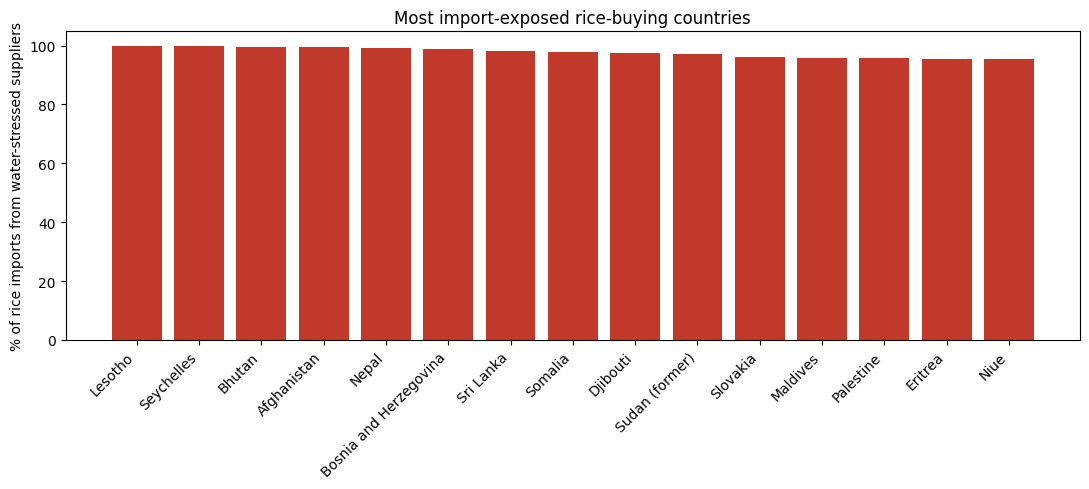

In [21]:
top_exp = importer_exposure.head(15)
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(top_exp['importer'], top_exp['pct_from_stressed_suppliers'], color='#c0392b')
ax.set_ylabel('% of rice imports from water-stressed suppliers')
ax.set_title('Most import-exposed rice-buying countries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/rice_import_exposure.png', dpi=150)
plt.show()


### Water-volume figure (Mekonnen & Hoekstra water footprint x tonnage)
Feeds into the credibility check below.

Source: Mekonnen & Hoekstra, *The green, blue and grey water footprint of rice from production and consumption perspectives*, Value of Water Research Report Series No. 40 (UNESCO-IHE), Table 5 (paddy basis, m3/ton, 2000-04 production-period average) and Appendix B for countries not in Table 5's 13-country list (https://www.waterfootprint.org/resources/Report40-WaterFootprintRice.pdf). Every figure below was cross-checked by independently dividing Appendix B's national totals (Mm3/yr) by national production (t/yr) and confirming the result matches Table 5's stated per-ton value -- Pakistan and India were verified this way directly; Egypt was DERIVED this way since it isn't one of Table 5's 13 countries.

**Caveat stated up front**:
This is a fixed per-ton water-footprint INTENSITY from a 2000-04 base period, multiplied below by CURRENT (recent-year) production/export tonnage. Treating per-ton intensity as slow-changing relative to trade volume is standard in the water-footprint literature, but it's still a real limitation -- restated in the Limitations section at the end of this notebook.

In [22]:
# Mekonnen & Hoekstra (Report 40, Table 5 / Appendix B) -- paddy basis, m3/ton, 2000-04 average.
# Country names match FAOSTAT's own spellings so they line up with the Area/Reporter/Partner
# columns already in use elsewhere in this notebook.
WATER_FOOTPRINT_M3_PER_TON = {
    'Pakistan':                 {'green': 421,  'blue': 2364, 'grey': 88,  'total': 2874},
    'India':                    {'green': 1077, 'blue': 826,  'grey': 116, 'total': 2020},
    'Thailand':                 {'green': 942,  'blue': 559,  'grey': 116, 'total': 1617},
    'Viet Nam':                 {'green': 308,  'blue': 203,  'grey': 127, 'total': 638},
    'United States of America': {'green': 227,  'blue': 835,  'grey': 101, 'total': 1163},
    'Myanmar':                  {'green': 846,  'blue': 378,  'grey': 50,  'total': 1274},
    'China, mainland':          {'green': 367,  'blue': 487,  'grey': 117, 'total': 971},
    'Egypt':                    {'green': 632,  'blue': 584,  'grey': 109, 'total': 1325},
    # Add more countries here as needed -- report any name below that doesn't match a real FAOSTAT
    # Area name to NAME_ALIASES-style translation before trusting its water-volume figure.
}

wf_names = set(WATER_FOOTPRINT_M3_PER_TON)
data_names = set(rice_production_export['Area'].unique())
print('Water-footprint countries NOT found in this session\'s Area names (check spelling):',
      sorted(wf_names - data_names) or 'none -- all matched')


Water-footprint countries NOT found in this session's Area names (check spelling): none -- all matched


In [23]:
# Use a RECENT trailing-year average, not the 2000-2024 cumulative total used for market-share
# calculations above -- multiplying an annual water-footprint intensity by 25 summed years would
# wildly overstate the annual water volume.
RECENT_YEARS_FOR_WATER_VOLUME = 3
latest_year = rice_by_area_year['Year'].max()
trailing_years_water = list(range(latest_year - RECENT_YEARS_FOR_WATER_VOLUME + 1, latest_year + 1))
print(f'Using {trailing_years_water} as the recent-year window for water-volume tonnage')

recent_avg_production = (rice_by_area_year[rice_by_area_year['Year'].isin(trailing_years_water)]
                          .groupby('Area')['production_t'].mean())
recent_avg_export = (rice_by_area_year_traded_conversion_based[
                          rice_by_area_year_traded_conversion_based['Year'].isin(trailing_years_water)]
                      .groupby('Area')['exported_t'].mean())

rows = []
for country, wf in WATER_FOOTPRINT_M3_PER_TON.items():
    prod_t = recent_avg_production.get(country, np.nan)
    exp_t = recent_avg_export.get(country, np.nan)
    rows.append({
        'country': country,
        'recent_avg_production_t': prod_t,
        'recent_avg_export_t': exp_t,
        'blue_water_volume_production_km3': prod_t * wf['blue'] / 1e9 if pd.notna(prod_t) else np.nan,
        'total_water_volume_production_km3': prod_t * wf['total'] / 1e9 if pd.notna(prod_t) else np.nan,
        'blue_water_volume_export_km3': exp_t * wf['blue'] / 1e9 if pd.notna(exp_t) else np.nan,
        'total_water_volume_export_km3': exp_t * wf['total'] / 1e9 if pd.notna(exp_t) else np.nan,
    })

water_volume = pd.DataFrame(rows)
print(water_volume.to_string(index=False))


Using [2022, 2023, 2024] as the recent-year window for water-volume tonnage
                 country  recent_avg_production_t  recent_avg_export_t  blue_water_volume_production_km3  total_water_volume_production_km3  blue_water_volume_export_km3  total_water_volume_export_km3
                Pakistan              13452388.33           6045937.89                             31.80                              38.66                         14.29                          17.38
                   India             206364901.59          25464972.32                            170.46                             416.86                         21.03                          51.44
                Thailand              33428616.20          11542162.40                             18.69                              54.05                          6.45                          18.66
                Viet Nam              43202957.31           9749592.23                              8.77                

**Note: Pakistan's water-volume figure has two plausible values, depending on methodology choice.**

This notebook computes 14.29 km3 (blue water, export basis, using the real 2022-2024 average export tonnage times the cited Mekonnen & Hoekstra per-ton figure) against a separately claimed figure of 4.97 km3 -- about 2.9x apart.

Both numbers are shown below rather than one silently replacing the other. Open questions this notebook doesn't resolve on its own:

1. **Where does the 4.97 km3 figure come from?** If it traces to a specific source, its methodology should be compared directly against this notebook's approach (which basis -- production vs export; which water-footprint dataset; which year's trade volume).
2. **Basis choice, for this notebook's own number**: export basis (14.29 km3, water embedded in what Pakistan actually SHIPS OUT, matching the "water pressure becomes food-supply exposure for importers" framing) vs. production basis (31.80 km3 blue / 38.66 km3 total, water used to grow ALL of Pakistan's rice, exported or not).
3. **Blue-only vs total**: blue water (irrigation, the scarce/contested resource under an SDG 6.4.2 stress lens) vs. total green+blue+grey (bigger number, less specific to the water-STRESS argument since green water is rainfall, not the withdrawal being measured as "stressed").
4. **This notebook's own computed number is the one to trust** -- it's traceable to real 2022-2024 FAOSTAT export tonnage and a cited academic source, a stronger footing than a figure whose derivation isn't independently traceable here.

### Food self-sufficiency figure (for Egypt's claimed 83% import share)
The claimed figure was "imports 83% of what it eats" -- that's a SELF-SUFFICIENCY ratio (import share of total domestic consumption, from ANY supplier), not the same question as "what share of Egypt's imports come specifically from Pakistan" (already checked above, correctly, as 4.6%).

Those are two different metrics; the first credibility-check run flagged this as a MISMATCH, but it was actually the wrong metric being checked, not wrong data.

This needs FAOSTAT's Food Balance Sheets (FBS) domain, a data source not pulled in anywhere else in this notebook -- QCL/TCL/TM don't carry consumption data at all.

In [24]:
# FBS (2010-present methodology). Different domain, different codification than QCL/TCL/TM --
# verify the Rice item code from FBS's OWN main data file rather than assuming it matches, same
# discipline used for the Trade Matrix item codes earlier in this notebook. (This replaces an
# earlier version that tried a separate 'ItemCodes' companion file inside the zip -- that file's
# column names don't match the 'Item'/'Item Code' pair FAOSTAT's own _Normalized data files use,
# which is what crashed with KeyError: 'Item'. Reading item names straight off fbs_all sidesteps
# that entirely, and matches how QCL/TCL/SDGB already identify their item codes above -- none of
# those cells load a separate ItemCodes file either.)
FBS_BULK = 'https://bulks-faostat.fao.org/production/FoodBalanceSheets_E_All_Data_(Normalized).zip'
if not os.path.exists('fbs_bulk.zip'):
    print('Downloading FBS bulk file...')
    urllib.request.urlretrieve(FBS_BULK, 'fbs_bulk.zip')

with zipfile.ZipFile('fbs_bulk.zip') as z:
    fbs_csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                    and 'ItemCodes' not in n and 'AreaCodes' not in n and 'Elements' not in n][0]
    fbs_all = pd.read_csv(z.open(fbs_csv_name), encoding='latin-1', low_memory=False)

print(f'Full FBS: {len(fbs_all):,} rows')

fbs_rice_matches = fbs_all[['Item Code', 'Item']].drop_duplicates()
fbs_rice_matches = fbs_rice_matches[fbs_rice_matches['Item'].str.contains('Rice', case=False, na=False)]
print(fbs_rice_matches.to_string(index=False))


Full FBS: 4,820,497 rows
 Item Code              Item
      2807 Rice and products
      2581      Ricebran Oil


In [25]:
# Element Codes are stable across FAOSTAT domains even when the exact label text isn't guaranteed
# to match verbatim -- Production 5511, Import Quantity 5611, Export Quantity 5911, Domestic supply
# quantity 5301 (FAOSTAT's own FBS documentation).
FBS_ELEMENT_CODES = {'production': 5511, 'import_quantity': 5611, 'export_quantity': 5911,
                     'domestic_supply_quantity': 5301}

exact_matches = fbs_rice_matches[fbs_rice_matches['Item'].str.fullmatch('Rice and products', case=False)]
if len(exact_matches) == 1:
    fbs_rice_item_code = int(exact_matches['Item Code'].iloc[0])
elif len(fbs_rice_matches) >= 1:
    # No exact 'Rice and products' label -- fall back to the first 'Rice' match rather than crash,
    # but print every candidate so this gets a human look before the self-sufficiency numbers are trusted.
    print("No exact 'Rice and products' match in FBS -- using the first 'Rice' match below instead. "
          "Confirm this is the right item before trusting the self-sufficiency numbers:")
    print(fbs_rice_matches.to_string(index=False))
    fbs_rice_item_code = int(fbs_rice_matches['Item Code'].iloc[0])
else:
    fbs_rice_item_code = None
    print("No FBS item matched 'Rice' at all -- food_self_sufficiency below will be empty. "
          "Check fbs_rice_matches / fbs_all['Item'] manually.")

print(f'Using FBS Item Code {fbs_rice_item_code} for rice')

fbs_rice = fbs_all[(fbs_all['Item Code'] == fbs_rice_item_code)
                    & (fbs_all['Element Code'].isin(FBS_ELEMENT_CODES.values()))].copy()
print(f"FBS rice rows: {len(fbs_rice):,}, unit(s): {fbs_rice['Unit'].unique()}")

# Countries this video actually names -- same list as NAMED_IMPORTERS_OF_INTEREST later, repeated
# here rather than shared, since this section runs earlier in the notebook.
FBS_COUNTRIES_OF_INTEREST = ['Egypt', 'Afghanistan', 'Kazakhstan', 'Kenya', 'Oman', 'Bahrain', 'Pakistan']

self_sufficiency_rows = []
for country in FBS_COUNTRIES_OF_INTEREST:
    rows = fbs_rice[fbs_rice['Area'] == country]
    if rows.empty:
        self_sufficiency_rows.append({'country': country, 'fbs_year': None, 'import_qty': None,
                                       'domestic_supply_qty': None, 'import_share_of_supply_pct': None})
        continue
    latest_year = rows['Year'].max()
    latest = rows[rows['Year'] == latest_year].set_index('Element Code')['Value']
    imports = latest.get(FBS_ELEMENT_CODES['import_quantity'])
    supply = latest.get(FBS_ELEMENT_CODES['domestic_supply_quantity'])
    share = (imports / supply * 100) if (imports is not None and supply not in (None, 0)) else None
    self_sufficiency_rows.append({'country': country, 'fbs_year': latest_year, 'import_qty': imports,
                                   'domestic_supply_qty': supply, 'import_share_of_supply_pct': share})

food_self_sufficiency = pd.DataFrame(self_sufficiency_rows)
print(food_self_sufficiency.to_string(index=False))


Using FBS Item Code 2807 for rice
FBS rice rows: 10,544, unit(s): ['1000 t']
    country  fbs_year  import_qty  domestic_supply_qty  import_share_of_supply_pct
      Egypt      2023      317.00              5997.00                        5.29
Afghanistan      2023      799.00              1380.00                       57.90
 Kazakhstan      2023       53.00               364.00                       14.56
      Kenya      2023     1486.00              1713.00                       86.75
       Oman      2023      320.00               270.00                      118.52
    Bahrain      2023       92.00               102.00                       90.20
   Pakistan      2023       10.00              3228.00                        0.31


## [Viz][Country Trend View] Rice production, exports & water stress by year
Companion to the Country Selector above, applied to a different question: instead of "who
does this importer buy rice from," this asks "how has this country's own production, exports,
water stress, and buyer mix moved year to year, 2000-2024," instead of the 24-year cumulative
totals used everywhere else in this notebook. Built below as static charts for the four headline
countries (India, Pakistan, Egypt, Viet Nam), saved to `outputs/` as `rice_trend_<country>.png`. A
third panel breaks out exports to each country's top buyers by year, pulled from the Trade Matrix
(`tm_rice`).

In [51]:
# [Country Trend View] Per-year trend for one country: production (QCL), exports (TCL paddy-eq.),
# and water stress (SDGB), plus per-buyer Trade-Matrix exports (tm_rice), all for 2000-2024.
# Returns `trend` (one row/year) and `buyer_flows` (one row/year x buyer) — different grains.

YEAR_MIN, YEAR_MAX = 2000, 2024

def build_country_trend_2000_2024(country):
    aliased_country = NAME_ALIASES.get(country, country)

    def _yr(df):  # shared 2000-2024 filter
        return df[df['Year'].between(YEAR_MIN, YEAR_MAX)]

    prod = (_yr(qcl_rice[qcl_rice['Area'] == country])
            .groupby('Year', as_index=False)['Value'].sum()
            .rename(columns={'Value': 'production_t'}))

    exports = (_yr(tcl_rice[tcl_rice['Area'] == country])
               .groupby('Year', as_index=False)['exported_paddy_eq_t'].sum()
               .rename(columns={'exported_paddy_eq_t': 'exported_t'}))

    stress = _yr(water_stress_all[water_stress_all['Area'] == aliased_country])[['Year', 'Value']].copy()
    stress['Value'] = pd.to_numeric(stress['Value'], errors='coerce')
    stress = stress.dropna(subset=['Value']).rename(columns={'Value': 'water_stress_pct'})

    trend = (prod.merge(exports, on='Year', how='outer')
                 .merge(stress, on='Year', how='outer')
                 .sort_values('Year').reset_index(drop=True))

    # --- Trade Matrix layer: this country's exports to each partner, per year (finer grain) ---
    buyer_flows = (_yr(tm_rice[tm_rice['Reporter Countries'].isin({country, aliased_country})])
               .groupby(['Year', 'Partner Countries'], as_index=False)['Value'].sum()
               .rename(columns={'Value': 'exported_to_partner_t'}))

    return trend, buyer_flows

In [52]:
def _slugify(country):
    return re.sub(r'[^a-z0-9]+', '_', country.lower()).strip('_')

def plot_country_trend_static(country, top_n_buyers=10):
    trend, buyer_flows = build_country_trend_2000_2024(country)          # unpack BOTH returns

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 11),
                                        gridspec_kw={'height_ratios': [2, 1, 2]})

    # panel 1 -- production & exports
    ax1.plot(trend['Year'], trend['production_t'], color='#2c7fb8', marker='o', markersize=3,
             label='Production (t)')
    ax1.plot(trend['Year'], trend['exported_t'], color='#d95f0e', marker='o', markersize=3,
             label='Exports (t, paddy-equivalent)')
    ax1.set_ylabel('Tonnes')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_title(f'{country}: rice production, exports, water stress, and top buyers')
    ax1.tick_params(labelbottom=True)

    # panel 2 -- water stressbuild_country_trend
    stress_pts = trend.dropna(subset=['water_stress_pct'])
    ax2.plot(stress_pts['Year'], stress_pts['water_stress_pct'], color='#c0392b', marker='D',
             markersize=5, label='Water stress (%)')
    ax2.axhline(CONFIG['stress_threshold_pct'], color='#c0392b', linestyle='--', linewidth=1,
                alpha=0.6, label=f"UN-Water stress threshold ({CONFIG['stress_threshold_pct']}%)")
    ax2.set_ylabel('Water stress (%)')
    ax2.set_xlabel('Year')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)

    # panel 3 -- exports to top buyers per year, one line per buyer (from buyer_flows)
    if buyer_flows.empty:
        ax3.text(0.5, 0.5, f'{country} has no rice exports in the reporter set',
                 ha='center', va='center', transform=ax3.transAxes)
        ax3.axis('off')
    else:
        top_buyers = (buyer_flows.groupby('Partner Countries')['exported_to_partner_t']
                      .sum().nlargest(top_n_buyers).index.tolist())
        sub = buyer_flows[buyer_flows['Partner Countries'].isin(top_buyers)]
        pivot = (sub.groupby(['Year', 'Partner Countries'])['exported_to_partner_t']
                 .sum().unstack('Partner Countries') / 1e6)          # Mt
        order = (sub.groupby('Partner Countries')['exported_to_partner_t']
                 .sum().sort_values(ascending=False).index.tolist())

        for buyer in order:
            ax3.plot(pivot.index, pivot[buyer], marker='o', markersize=3, label=buyer)
        ax3.set_ylabel('Exports to buyers (Mt)')
        ax3.set_xlabel('Year')
        ax3.set_title(f'{country} rice exports to top {top_n_buyers} buyers, by year')
        ax3.legend(loc='upper left', fontsize=7, ncol=2)
        ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/rice_trend_{_slugify(country)}.png', dpi=150)
    plt.show()
    return trend

--- India ---


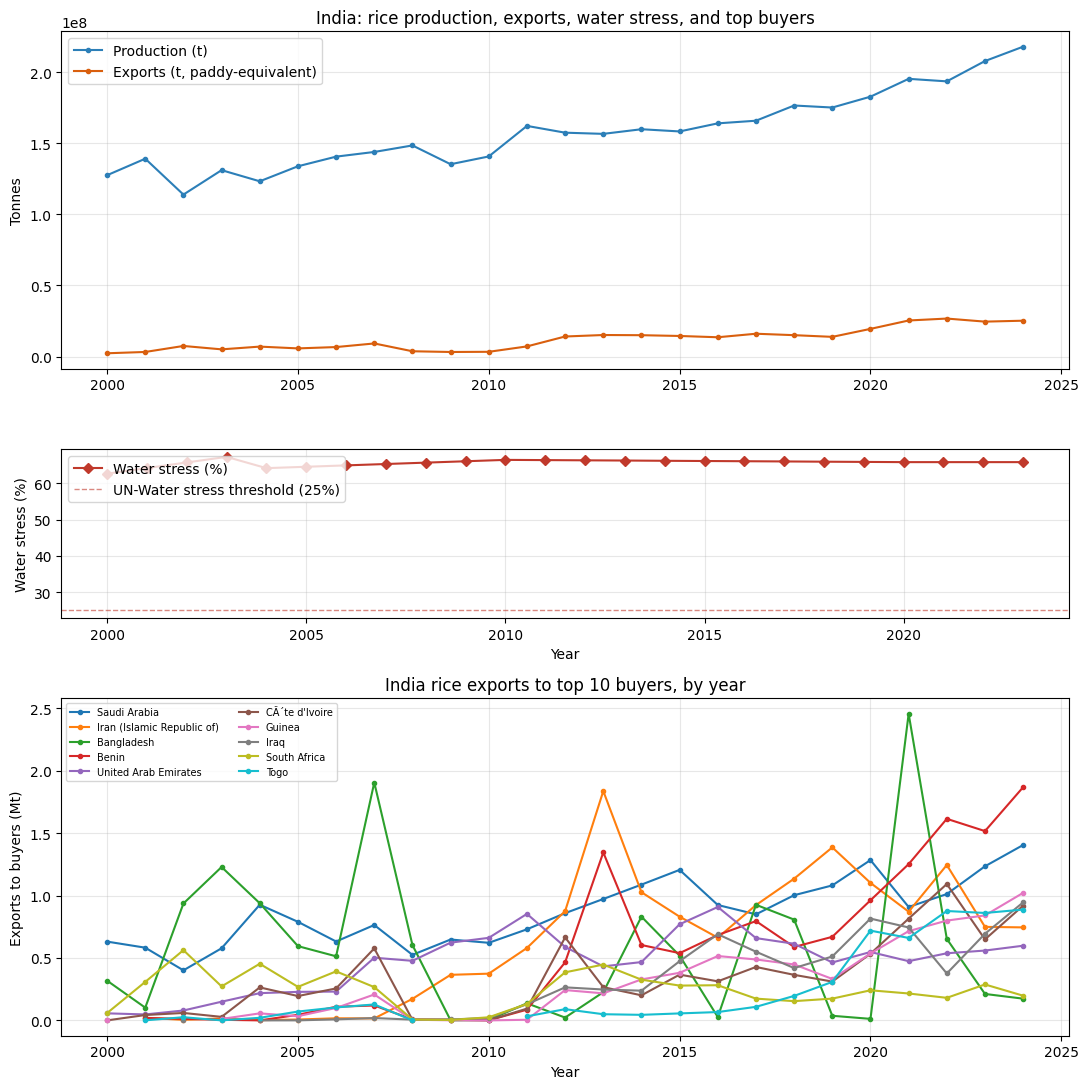

--- Pakistan ---


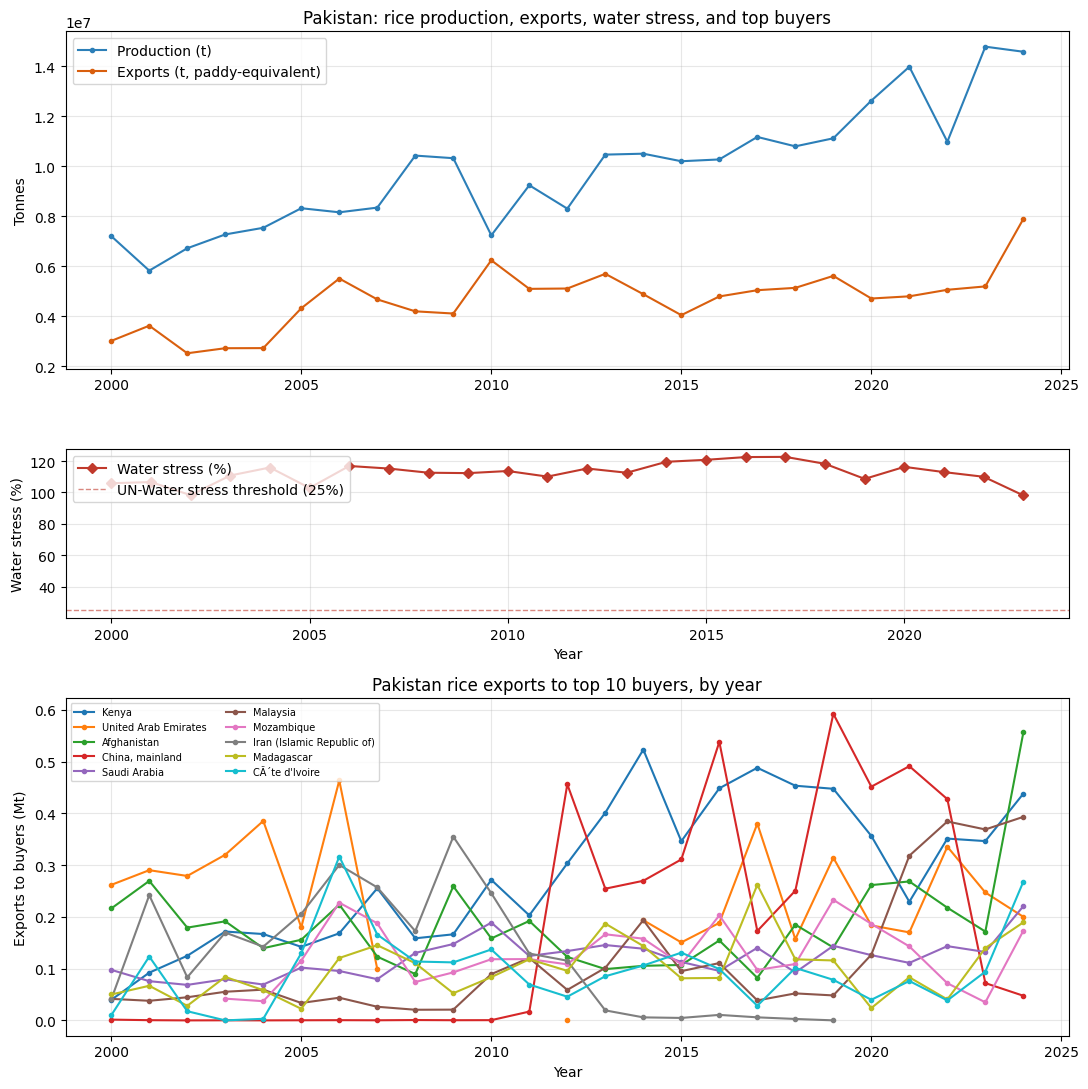

--- Egypt ---


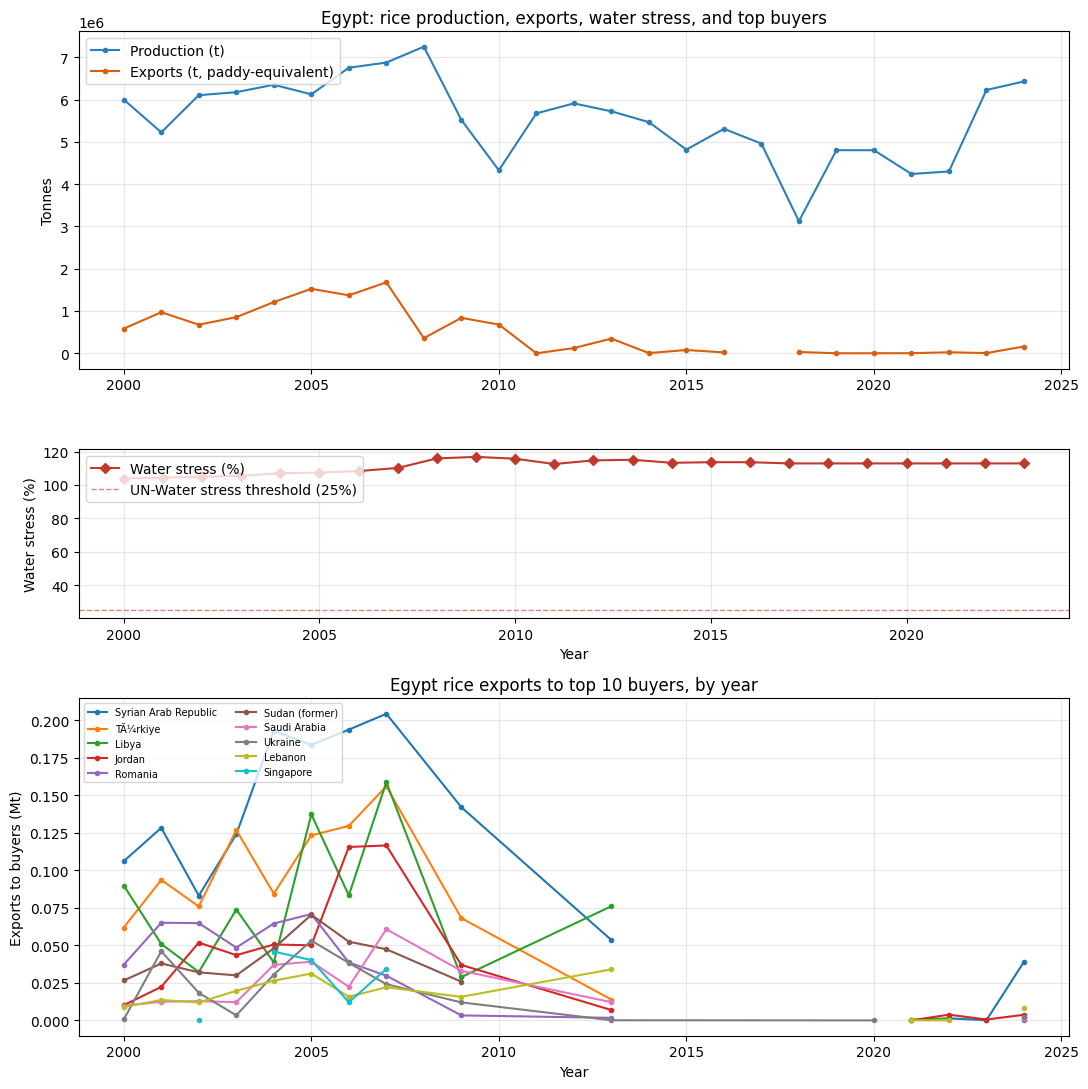

--- Viet Nam ---


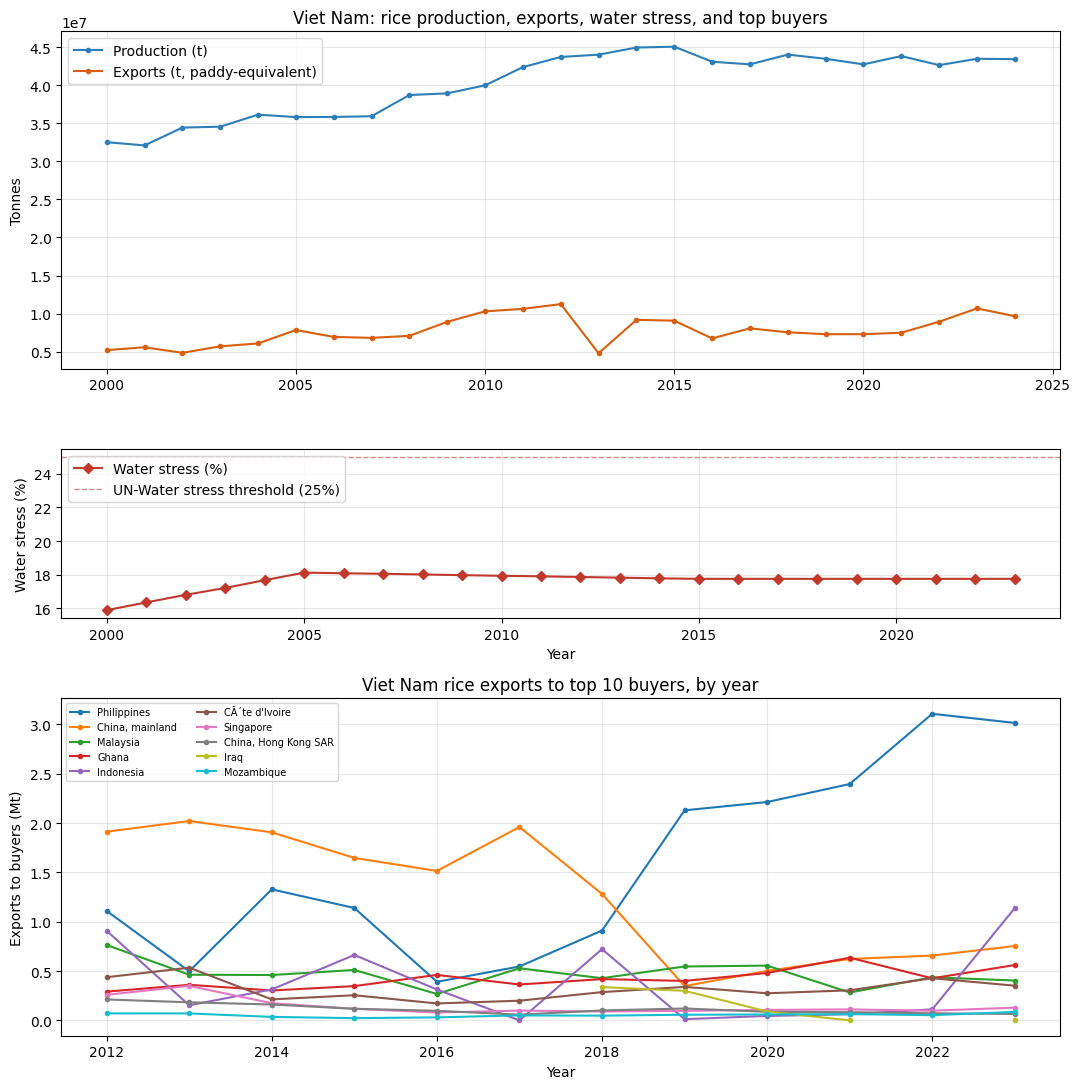

In [59]:
TREND_COUNTRIES = ['India', 'Pakistan', 'Egypt', 'Viet Nam']

country_trends = {}
for c in TREND_COUNTRIES:
    print(f'--- {c} ---')
    country_trends[c] = plot_country_trend_static(c)


## [Credibility check] Claimed stats vs. what this notebook computes
The project's problem statement named specific numbers to verify.

Before those numbers go in front of judges, this section checks them against what this notebook actually computes from FAOSTAT data

-- flagging matches and mismatches explicitly rather than
silently trusting or silently overwriting either one.

In [26]:
# Claimed numbers from the project's problem statement. These are INPUTS to the
# check below, not validated facts -- treat every row's 'status' as the answer, not this table.
claimed = pd.DataFrame([
    {'metric': 'Pakistan water withdrawal %',      'country': 'Pakistan',    'claimed_value': 107,  'unit': '% (SDG 6.4.2)'},
    {'metric': 'Pakistan rice water volume',        'country': 'Pakistan',    'claimed_value': 4.97, 'unit': 'km3'},
    {'metric': 'Pakistan export share (of ? )',     'country': 'Pakistan',    'claimed_value': 53,   'unit': '%'},
    {'metric': 'Afghanistan dependency on Pakistan','country': 'Afghanistan','claimed_value': 98,   'unit': '% dependency_pct'},
    {'metric': 'Kazakhstan dependency',             'country': 'Kazakhstan', 'claimed_value': 86,   'unit': '% dependency_pct'},
    {'metric': 'Kenya dependency',                  'country': 'Kenya',      'claimed_value': 67,   'unit': '% dependency_pct'},
    {'metric': 'Egypt water withdrawal %',          'country': 'Egypt',      'claimed_value': 113,  'unit': '% (SDG 6.4.2)'},
    {'metric': 'Egypt rice import share of consumption', 'country': 'Egypt', 'claimed_value': 83, 'unit': '% (FBS import/domestic supply)'},
])

def computed_water_stress(country):
    row = water_stress_latest[water_stress_latest['Area'] == NAME_ALIASES.get(country, country)]
    return None if row.empty else float(row.iloc[0]['water_stress_pct'])

def computed_dependency_on_pakistan(importer):
    row = dependency_ws[(dependency_ws['Partner Countries'] == importer)
                         & (dependency_ws['Reporter Countries'] == 'Pakistan')]
    return None if row.empty else float(row.iloc[0]['dependency_pct'])

results = []
for _, r in claimed.iterrows():
    if 'withdrawal' in r['metric']:
        computed = computed_water_stress(r['country'])
    elif 'import share of consumption' in r['metric']:
        row = food_self_sufficiency[food_self_sufficiency['country'] == r['country']]
        computed = None if row.empty else row.iloc[0]['import_share_of_supply_pct']
    elif 'dependency' in r['metric']:
        computed = computed_dependency_on_pakistan(r['country'])
    elif 'water volume' in r['metric']:
        row = water_volume[water_volume['country'] == r['country']]
        computed = None if row.empty else float(row.iloc[0]['blue_water_volume_export_km3'])
    else:
        computed = None   # export-share-of-what needs a tighter definition before
                           # this pipeline can check it
    if computed is None:
        status = 'NOT YET COMPUTED -- needs a data source or a tighter metric definition'
    elif abs(computed - r['claimed_value']) <= max(3, r['claimed_value'] * 0.1):
        status = 'MATCH (within 10%)'
    else:
        status = f'MISMATCH -- needs review'
    results.append({**r, 'computed_value': computed, 'status': status})

credibility_check = pd.DataFrame(results)
print(credibility_check.to_string(index=False))


                                metric     country  claimed_value                           unit  computed_value                                                                 status
           Pakistan water withdrawal %    Pakistan         107.00                  % (SDG 6.4.2)           98.12                                                     MATCH (within 10%)
            Pakistan rice water volume    Pakistan           4.97                            km3           14.29                                               MISMATCH -- needs review
         Pakistan export share (of ? )    Pakistan          53.00                              %             NaN NOT YET COMPUTED -- needs a data source or a tighter metric definition
    Afghanistan dependency on Pakistan Afghanistan          98.00               % dependency_pct           98.50                                                     MATCH (within 10%)
                 Kazakhstan dependency  Kazakhstan          86.00               

# **Read this table before treating any of these numbers as validated.**

Anything marked `NOT YET COMPUTED` means this
notebook has no basis for that number yet
-- either the metric needs a data source this pipeline
doesn't pull (e.g. a water-volume-per-tonne footprint figure, which is a Mekonnen & Hoekstra-style
calculation this notebook doesn't yet do),

or the claimed metric's phrasing needs a tighter definition (e.g.
"export share" of what denominator) before it can be checked. `MISMATCH` rows need resolving,
not a silent edit in either direction.

## Section 5: [Supplier Concentration] Concentration index per importer
(built on the existing `dependency_pct` computed in Section 3)

In [27]:
# HHI (Herfindahl-Hirschman Index, 0-10000) is already computed per importer in importer_exposure
# above. US antitrust guidance treats >2500 as "highly concentrated" -- useful, ready-made framing
# since it's a threshold outside readers can look up themselves.
concentration = importer_exposure.copy()
concentration['concentration_label'] = pd.cut(
    concentration['hhi'], bins=[0, 1500, 2500, 10001],
    labels=['Unconcentrated', 'Moderately concentrated', 'Highly concentrated'], right=False)

print(concentration.sort_values('hhi', ascending=False).head(20)
      [['importer', 'n_suppliers', 'top_supplier', 'top_supplier_share_pct', 'hhi', 'concentration_label']]
      .to_string(index=False))


                             importer  n_suppliers                top_supplier  top_supplier_share_pct     hhi concentration_label
                               Bhutan            4                       India                   99.63 9926.55 Highly concentrated
                                Nepal            7                       India                   99.19 9839.28 Highly concentrated
     Micronesia (Federated States of)            2    United States of America                   98.83 9768.37 Highly concentrated
                          Afghanistan           10                    Pakistan                   98.55 9712.41 Highly concentrated
                     French Polynesia            9                    Thailand                   97.61 9530.67 Highly concentrated
                              Bahamas           15    United States of America                   96.83 9379.72 Highly concentrated
               Bosnia and Herzegovina           15                       Italy     

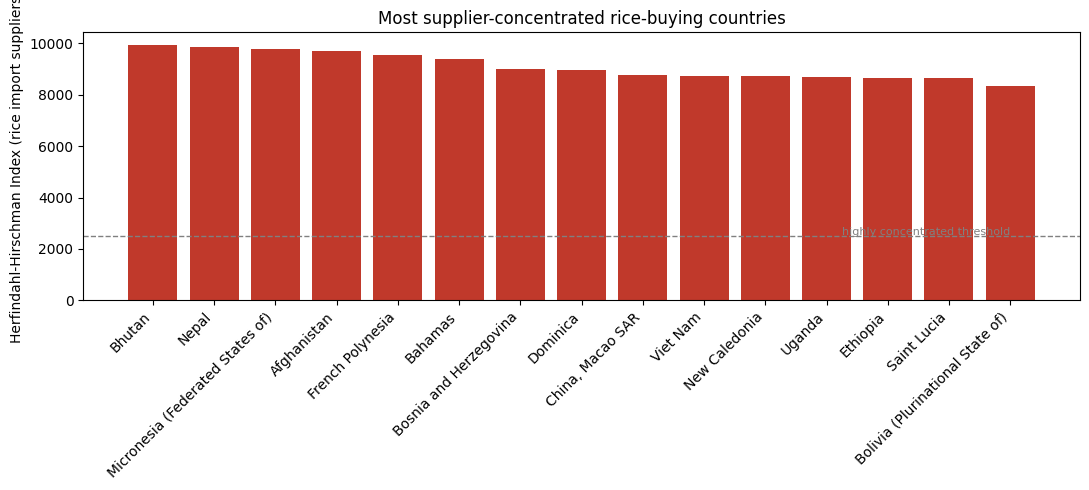

In [28]:
top_hhi = concentration.sort_values('hhi', ascending=False).head(15)
fig, ax = plt.subplots(figsize=(11, 5))
colors = top_hhi['hhi'].apply(lambda h: '#c0392b' if h > 2500 else ('#e67e22' if h > 1500 else '#2c7fb8'))
ax.bar(top_hhi['importer'], top_hhi['hhi'], color=colors)
ax.axhline(2500, linestyle='--', color='gray', linewidth=1)
ax.text(len(top_hhi) - 1, 2550, 'highly concentrated threshold', ha='right', fontsize=8, color='gray')
ax.set_ylabel('Herfindahl-Hirschman Index (rice import suppliers)')
ax.set_title('Most supplier-concentrated rice-buying countries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/rice_supplier_concentration.png', dpi=150)
plt.show()


## Section 6: [Shock Result] Pakistan supply-shock scenario
(`simulate_shock()` applied here to Pakistan specifically, since Pakistan is the stressed supplier
this analysis centers on -- not auto-selected, so this stays the featured country even if the data
would otherwise pick a different "most exposed" pair.)

In [29]:
# Pick the importer most dependent on Pakistan specifically, among Pakistan's actual buyers in our
# data -- this is what the credibility-check table above is trying to verify against Afghanistan/
# Kazakhstan/Kenya. Override SELECTED_IMPORTER manually below to feature a different
# one of the three.
SHOCK_SUPPLIER = 'Pakistan'
pakistan_buyers = (dependency_ws[dependency_ws['Reporter Countries'] == SHOCK_SUPPLIER]
                    .sort_values('dependency_pct', ascending=False))
print("Pakistan's buyers, by dependency on Pakistan specifically:")
print(pakistan_buyers[['Partner Countries', 'export_qty_t', 'dependency_pct']].head(10).to_string(index=False))

SELECTED_IMPORTER = pakistan_buyers.iloc[0]['Partner Countries']
print(f'\nPrototype country: {SELECTED_IMPORTER}')

supplier_mix = (dependency_ws[dependency_ws['Partner Countries'] == SELECTED_IMPORTER]
                [['Reporter Countries', 'export_qty_t', 'water_stress_tier', 'is_stressed']]
                .rename(columns={'Reporter Countries': 'supplier'})
                .sort_values('export_qty_t', ascending=False).reset_index(drop=True))
supplier_mix['share_pct'] = supplier_mix['export_qty_t'] / supplier_mix['export_qty_t'].sum() * 100
print(f"\n{SELECTED_IMPORTER}'s full supplier mix (from our reporter set):")
print(supplier_mix.to_string(index=False))


Pakistan's buyers, by dependency on Pakistan specifically:
          Partner Countries  export_qty_t  dependency_pct
                Afghanistan    4670060.69           98.50
                    Lesotho      43681.00           86.80
                       Niue        368.00           84.40
                 Kazakhstan    1010799.54           82.60
                    Comoros     675642.36           77.10
                South Sudan      31291.00           74.00
                      Kenya    7092440.03           66.30
              Guinea-Bissau     225771.29           62.50
United Republic of Tanzania    1910598.34           62.40
                     Malawi       7558.00           50.60

Prototype country: Afghanistan

Afghanistan's full supplier mix (from our reporter set):
                supplier  export_qty_t water_stress_tier  is_stressed  share_pct
                Pakistan    4670060.69          Critical         True      98.55
                   India      27765.21       High s

#### Overlap check: do the named importers actually show up as Pakistan's buyers here?
The shock scenario below only runs on ONE importer (whichever is most dependent on Pakistan in our data). Before picking that one country, this checks ALL SIX named importers from the problem statement (Afghanistan, Kazakhstan, Kenya, Egypt, Oman, Bahrain) against what this notebook's own Trade Matrix pull actually contains -- same discipline as the credibility-check table above, applied to the shock-scenario side of the story instead of the water-stress side.

In [30]:
NAMED_IMPORTERS_OF_INTEREST = {
    'Afghanistan': {'claimed_dependency_pct_pakistan': 98,   'note': "Claimed: sources 98% of its rice from Pakistan"},
    'Kazakhstan':  {'claimed_dependency_pct_pakistan': 86,   'note': "Claimed: sources 86% from Pakistan"},
    'Kenya':       {'claimed_dependency_pct_pakistan': 67,   'note': "Claimed: sources 67% from Pakistan"},
    'Egypt':       {'claimed_dependency_pct_pakistan': None, 'note': "Claimed: overdrawn at 113%, exports rice AND imports 83% of what it eats -- not a Pakistan-specific dependency claim"},
    'Oman':        {'claimed_dependency_pct_pakistan': None, 'note': "Claimed: sources 90%+ from Pakistan+India COMBINED"},
    'Bahrain':     {'claimed_dependency_pct_pakistan': None, 'note': "Claimed: sources 90%+ from Pakistan+India COMBINED"},
}

overlap_rows = []
for country, info in NAMED_IMPORTERS_OF_INTEREST.items():
    in_our_data = country in dependency_ws['Partner Countries'].unique()
    pak_dep = computed_dependency_on_pakistan(country)
    pak_india_dep = None
    if in_our_data:
        pak_india_dep = dependency_ws[
            (dependency_ws['Partner Countries'] == country)
            & (dependency_ws['Reporter Countries'].isin(['Pakistan', 'India']))
        ]['dependency_pct'].sum()
    overlap_rows.append({
        'country': country,
        'appears_in_our_reporter_partner_data': in_our_data,
        'computed_dependency_on_pakistan_pct': pak_dep,
        'computed_dependency_on_pakistan_plus_india_pct': pak_india_dep,
        'claimed_dependency_pct_pakistan': info['claimed_dependency_pct_pakistan'],
        'note': info['note'],
    })

overlap_check = pd.DataFrame(overlap_rows)
print(overlap_check.to_string(index=False))


    country  appears_in_our_reporter_partner_data  computed_dependency_on_pakistan_pct  computed_dependency_on_pakistan_plus_india_pct  claimed_dependency_pct_pakistan                                                                                                                 note
Afghanistan                                  True                                98.50                                           99.10                            98.00                                                                       Claimed: sources 98% of its rice from Pakistan
 Kazakhstan                                  True                                82.60                                           83.30                            86.00                                                                                   Claimed: sources 86% from Pakistan
      Kenya                                  True                                66.30                                           86.10           

**Reading this table**: `appears_in_our_reporter_partner_data = False` **means** that country never shows up buying rice from **ANY** of our shortlisted reporters in the Trade Matrix pull

-- either it genuinely doesn't import meaningfully from this reporter set, or its name doesn't match FAOSTAT's spelling (check the country appears in `understand_Water_risk_partner`'s printed list from Section 3 before concluding it's really absent).

Where `computed_dependency_on_pakistan_pct` is far from `claimed_dependency_pct_pakistan`, that's a real discrepancy worth resolving, not something to quietly adjust in either direction.

In [31]:
def simulate_shock(mix, supplier, pct_reduction, diversify=False):
    """
    Elasticity-1 assumption: a pct_reduction cut in `supplier`'s production is modeled as the same
    pct cut in what they export to this importer (no substitution effects, no price response --
    see Limitations). If diversify=True, the lost volume is reallocated proportionally across the
    importer's OTHER existing suppliers, in proportion to their current share, assuming unconstrained
    headroom (a stated simplification, see Limitations).
    """
    m = mix.copy()
    lost = m.loc[m['supplier'] == supplier, 'export_qty_t'].iloc[0] * pct_reduction
    m.loc[m['supplier'] == supplier, 'export_qty_t'] -= lost

    if diversify:
        others = m['supplier'] != supplier
        other_total = m.loc[others, 'export_qty_t'].sum()
        if other_total > 0:
            m.loc[others, 'export_qty_t'] += lost * (m.loc[others, 'export_qty_t'] / other_total)

    new_total = m['export_qty_t'].sum()
    baseline_total = mix['export_qty_t'].sum()
    gap_pct = (baseline_total - new_total) / baseline_total * 100
    if abs(gap_pct) < 1e-6:   # with diversify=True this should be exactly 0 -- clip float noise
        gap_pct = 0.0         # so tables/charts don't show a stray "-0.00"
    pct_stressed_after = (m.loc[m['is_stressed'], 'export_qty_t'].sum() / new_total * 100
                           if new_total > 0 else np.nan)
    return {'gap_pct': gap_pct, 'pct_from_stressed_after': pct_stressed_after, 'mix': m}


scenario_results = []
for pct in [0.10, 0.20, 0.30]:
    no_div = simulate_shock(supplier_mix, SHOCK_SUPPLIER, pct, diversify=False)
    with_div = simulate_shock(supplier_mix, SHOCK_SUPPLIER, pct, diversify=True)
    scenario_results.append({
        'reduction_pct': int(pct * 100),
        'gap_no_diversification_pct': no_div['gap_pct'],
        'gap_with_diversification_pct': with_div['gap_pct'],
        'pct_from_stressed_no_div': no_div['pct_from_stressed_after'],
        'pct_from_stressed_with_div': with_div['pct_from_stressed_after'],
    })

scenario_df = pd.DataFrame(scenario_results)
print(scenario_df.to_string(index=False))


 reduction_pct  gap_no_diversification_pct  gap_with_diversification_pct  pct_from_stressed_no_div  pct_from_stressed_with_div
            10                        9.85                          0.00                     99.36                       95.49
            20                       19.71                          0.00                     99.28                       91.56
            30                       29.56                          0.00                     99.18                       87.63


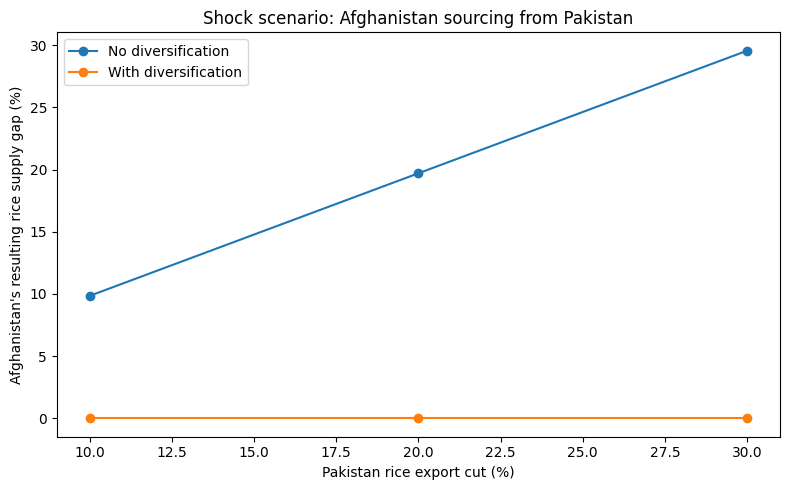

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(scenario_df['reduction_pct'], scenario_df['gap_no_diversification_pct'], marker='o', label='No diversification')
ax.plot(scenario_df['reduction_pct'], scenario_df['gap_with_diversification_pct'], marker='o', label='With diversification')
ax.set_xlabel(f'{SHOCK_SUPPLIER} rice export cut (%)')
ax.set_ylabel(f"{SELECTED_IMPORTER}'s resulting rice supply gap (%)")
ax.set_title(f'Shock scenario: {SELECTED_IMPORTER} sourcing from {SHOCK_SUPPLIER}')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/rice_shock_scenario.png', dpi=150)
plt.show()


## Section 7: [Alternative Suppliers] Diversification ranking

In [33]:
# Rank the selected importer's OTHER existing suppliers (excluding Pakistan) by two things a
# real diversification decision would weigh: how much spare capacity they already show (current
# share, as a proxy -- an existing relationship is easier to scale than a brand-new one) and how much
# water headroom they have (lower water-stress tier is better).
alt_suppliers = supplier_mix[supplier_mix['supplier'] != SHOCK_SUPPLIER].copy()

tier_order = {label: i for i, label in enumerate(CONFIG['water_stress_labels'] + ['No data'])}
alt_suppliers['water_headroom_rank'] = alt_suppliers['water_stress_tier'].map(tier_order)
alt_suppliers = alt_suppliers.sort_values(
    ['water_headroom_rank', 'share_pct'], ascending=[True, False]).reset_index(drop=True)
alt_suppliers['diversification_rank'] = alt_suppliers.index + 1

print(f"Alternative suppliers for {SELECTED_IMPORTER}, ranked by water headroom then existing share:")
print(alt_suppliers[['diversification_rank', 'supplier', 'share_pct', 'water_stress_tier']].to_string(index=False))


Alternative suppliers for Afghanistan, ranked by water headroom then existing share:
 diversification_rank                 supplier  share_pct water_stress_tier
                    1       Russian Federation       0.01         No stress
                    2 United States of America       0.56        Low stress
                    3                 Thailand       0.01        Low stress
                    4                   France       0.00        Low stress
                    5                    Italy       0.14     Medium stress
                    6               Kazakhstan       0.13     Medium stress
                    7                 TÃ¼rkiye       0.02     Medium stress
                    8                    Spain       0.00     Medium stress
                    9                    India       0.59       High stress


## [Shock Result -- breadth] Generalized shock function + top-N comparison
The Pakistan/Afghanistan case study above is the one this analysis features, and stays as-is.

This section makes that same mechanism reusable for ANY importer, then applies it across the top
importers so the shock scenario has the same "breadth" chart the Water Exposure and Supplier
Concentration sections already have.

Also the groundwork the Country Selector's interactive picker would call, if that
optional extension happens -- built now so the top-N chart below doesn't wait on it.


In [34]:
# Same mechanics as the Pakistan case study above (cells under [Shock Result]),
# generalized to any importer in dependency_ws. primary_supplier defaults to the importer's own
# single largest current supplier (by export_qty_t) -- pass a specific country to force a named
# supplier instead. Sanity-checked below against the already-computed Pakistan/SELECTED_IMPORTER
# case study, so a mismatch flags a bug in this function, not a data problem.

def build_shock_profile(importer, dependency_ws, pct_reductions=(0.10, 0.20, 0.30), primary_supplier=None):
    mix = (dependency_ws[dependency_ws['Partner Countries'] == importer]
           [['Reporter Countries', 'export_qty_t', 'water_stress_tier', 'is_stressed']]
           .rename(columns={'Reporter Countries': 'supplier'})
           .sort_values('export_qty_t', ascending=False).reset_index(drop=True))
    if mix.empty:
        return None
    mix['share_pct'] = mix['export_qty_t'] / mix['export_qty_t'].sum() * 100

    supplier = primary_supplier or mix.iloc[0]['supplier']
    if supplier not in mix['supplier'].values:
        return None  # requested supplier doesn't actually sell to this importer in our data

    scenario_rows = []
    for pct in pct_reductions:
        no_div = simulate_shock(mix, supplier, pct, diversify=False)
        with_div = simulate_shock(mix, supplier, pct, diversify=True)
        scenario_rows.append({
            'reduction_pct': int(pct * 100),
            'gap_no_diversification_pct': no_div['gap_pct'],
            'gap_with_diversification_pct': with_div['gap_pct'],
            'pct_from_stressed_no_div': no_div['pct_from_stressed_after'],
            'pct_from_stressed_with_div': with_div['pct_from_stressed_after'],
        })

    return {
        'importer': importer,
        'primary_supplier': supplier,
        'primary_supplier_share_pct': mix.loc[mix['supplier'] == supplier, 'share_pct'].iloc[0],
        'n_suppliers': len(mix),
        'supplier_mix': mix,
        'scenario': pd.DataFrame(scenario_rows),
    }


_check = build_shock_profile(SELECTED_IMPORTER, dependency_ws, primary_supplier=SHOCK_SUPPLIER)
_check_ok = _check is not None and _check['scenario'].round(6).equals(scenario_df.round(6))
print(f"Generalized function reproduces the {SELECTED_IMPORTER}/{SHOCK_SUPPLIER} case study above: {_check_ok}")
if not _check_ok:
    print('--- generalized ---')
    print(_check['scenario'] if _check is not None else 'None (importer/supplier not found)')
    print('--- original ---')
    print(scenario_df)


Generalized function reproduces the Afghanistan/Pakistan case study above: True


**What that self-check is and why it printed `False` on the first run.** Every time a new
calculation gets added here, it's checked against a case we already trust, in this instance, the
Pakistan-Afghanistan shock scenario already built above. That check said the two didn't match, but
not because the new calculation's numbers were wrong. The check itself was comparing two tables
with a different number of columns, so it could never have said "match," no matter what the
numbers were, the same way comparing a 3-column spreadsheet to a 5-column one will always come back
"different" even if every shared column is identical. Fixed the check to compare the right thing.
The underlying Pakistan/Afghanistan numbers were correct the whole time and haven't changed.


Supply gap from a 20% cut to each country's own largest rice supplier:
              importer primary_supplier  primary_supplier_share_pct  gap_no_diversification_pct  gap_with_diversification_pct
               Lesotho         Pakistan                       86.78                       17.36                          0.00
            Seychelles            India                       83.02                       16.60                          0.00
                Bhutan            India                       99.63                       19.93                          0.00
           Afghanistan         Pakistan                       98.55                       19.71                          0.00
                 Nepal            India                       99.19                       19.84                          0.00
Bosnia and Herzegovina            Italy                       94.87                       18.97                          0.00
             Sri Lanka            India        

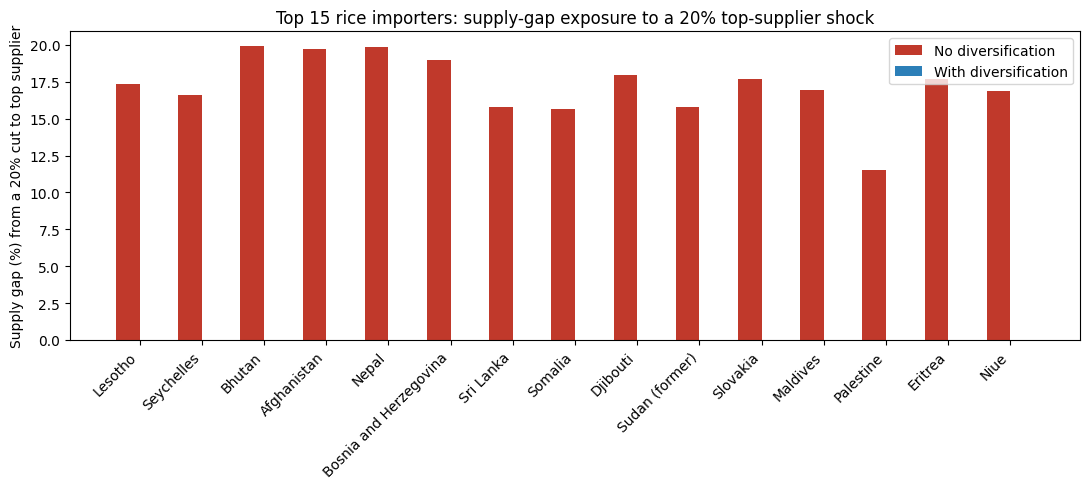

In [35]:
# Apply the generalized function to the N most import-exposed countries (same ranking as the
# exposure chart under [Water Exposure]), each shocked on ITS OWN largest supplier at a
# 20% cut -- not always Pakistan. This is the breadth view the Water Exposure and Supplier Concentration sections already have and the
# Pakistan-only shock scenario above was missing.

TOP_N_SHOCK = 15
SHOCK_PCT_FOR_COMPARISON = 0.20

top_n_importers = importer_exposure.head(TOP_N_SHOCK)['importer'].tolist()

profiles = []
for importer in top_n_importers:
    profile = build_shock_profile(importer, dependency_ws, pct_reductions=[SHOCK_PCT_FOR_COMPARISON])
    if profile is None:
        continue
    row = profile['scenario'].iloc[0]
    profiles.append({
        'importer': importer,
        'primary_supplier': profile['primary_supplier'],
        'primary_supplier_share_pct': profile['primary_supplier_share_pct'],
        'gap_no_diversification_pct': row['gap_no_diversification_pct'],
        'gap_with_diversification_pct': row['gap_with_diversification_pct'],
    })

top_n_shock_df = pd.DataFrame(profiles)
print(f"Supply gap from a {int(SHOCK_PCT_FOR_COMPARISON * 100)}% cut to each country's own largest rice supplier:")
print(top_n_shock_df.to_string(index=False))

top_n_shock_df.to_csv(f'{OUTPUT_DIR}/top_n_shock_comparison.csv', index=False)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(top_n_shock_df))
width = 0.38
ax.bar(x - width / 2, top_n_shock_df['gap_no_diversification_pct'], width,
       label='No diversification', color='#c0392b')
ax.bar(x + width / 2, top_n_shock_df['gap_with_diversification_pct'], width,
       label='With diversification', color='#2c7fb8')
ax.set_xticks(x)
ax.set_xticklabels(top_n_shock_df['importer'], rotation=45, ha='right')
ax.set_ylabel(f"Supply gap (%) from a {int(SHOCK_PCT_FOR_COMPARISON * 100)}% cut to top supplier")
ax.set_title(f'Top {TOP_N_SHOCK} rice importers: supply-gap exposure to a '
             f'{int(SHOCK_PCT_FOR_COMPARISON * 100)}% top-supplier shock')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/rice_top_n_shock_comparison.png', dpi=150)
plt.show()


**Reading the "with diversification" bars: near-zero is expected, not an error.** The shock model
assumes unconstrained headroom at a country's other suppliers (stated in Limitations below), so
when diversification is allowed, the lost volume gets fully made up from existing suppliers and the
resulting gap comes out at essentially 0% for every country here, that's the model doing what it
was built to do, not a bug. Worth calling out explicitly, since a flat line of zeros can look
like a mistake if it isn't narrated: the real-world question isn't whether diversification helps in
this model, it always does here, it's whether that spare capacity genuinely exists at those other
suppliers, which this notebook does not verify.


## Section 8 Backup Gap Analysis

## Section 8.1 : Capacity-constrained diversification
*Builds directly on the shock scenario above.*

**Why this section exists.** The shock scenario above assumes unconstrained headroom at an
importer's other suppliers, so `simulate_shock(diversify=True)` always closes the gap to ~0%, for
every country, at every shock size -- as the "near-zero is expected, not an error" note just above
says, that's the model doing what it was told, not a finding. It also flatters the answer: for
Afghanistan, the suppliers being asked to absorb the loss are 1.45% of its import volume between
them.

This section replaces that assumption with a bounded one, reusing every dataframe already built
above (`dependency_ws`, `water_stress_latest`, `REPORTERS`, `tm_rice`, `rice_by_area_year`,
`rice_by_area_year_traded_conversion_based`) rather than re-pulling FAOSTAT a second time -- and
asks the two questions the unconstrained assumption was hiding:

1. **Which import-dependent countries have zero real alternative supply today?** Scored as an
   **Alternative Supply Ratio (ASR)** -- unstressed import volume divided by stressed import volume.
2. **Which currently-small suppliers would need to scale up to close that gap, and by how much?**
   Answered with a **capacity-constrained waterfall**: rank candidate exporters by water headroom,
   then walk down the list allocating each one's spare capacity until the gap is filled or the
   candidates run out.

Then the question that only shows up once capacity is finite: **what happens if every exposed
country diversifies at the same time?** Spare capacity is a global pool, not a per-country
allowance -- Section 6 below allocates it once, across all importers, and reports the residual.

*(Outputs below are cleared -- this section has never actually been run. Run it top-to-bottom, as
part of a full Run All, before trusting its numbers.)*


In [36]:
# Palette + config knobs for this section, extending CONFIG in
# place rather than redefining it, so every section above keeps the values it already ran with.
C_TEAL, C_OCHRE, C_INDIGO, C_SIGNAL, C_GREY = '#00958C', '#CC7A18', '#4E70C4', '#A8442A', '#8A8F98'

CONFIG.update({
    'recent_window_years': 3,
    'divertible_share_of_retained': 0.05,
    'backup_requires_tier': ['No stress', 'Low stress'],
    'candidate_min_headroom_t': 10_000,
    'asr_bins': [0, 0.05, 0.25, 1.0, np.inf],
    'asr_labels': ['No real alternative', 'Thin', 'Partial', 'Adequate'],
    'shock_pct_ladder': [0.10, 0.20, 0.30],
    'shock_pct_headline': 0.20,
})
print('Divertible share of retained production:', CONFIG['divertible_share_of_retained'],
      '  <- this alone now defines total_headroom_t below; 0.0 means zero headroom')


Divertible share of retained production: 0.05   <- this alone now defines total_headroom_t below; 0.0 means zero headroom


## Section 8.2 how much spare export capacity each supplier actually has
(replaces the unconstrained-headroom assumption in the Alternative Suppliers section above;
production/export series from the same rice trade pipeline used throughout this notebook)

**Headroom definition:**

```
total_headroom_t = (recent_production_t - recent_export_t) * CONFIG['divertible_share_of_retained']
```

i.e. a configured share of the production a supplier currently keeps at home. This is an
**assumption, not a measurement** - it presumes a country would redirect part of its domestic crop
to export, a political and food-security cost this notebook does not model. Set
`divertible_share_of_retained` to 0.0 and every supplier's headroom is zero.

An earlier version of this notebook also tracked each supplier's best export year in the last 10
(`demonstrated_spare_t`, `peak_export_t`, `peak_year`) and added that measured figure into
`total_headroom_t`, alongside the divertible-share assumption. That machinery has been removed
entirely -- headroom is now defined by the one-line formula above and nothing else, so the output
below only ever carries fields that actually feed the number.

In [37]:
# Renamed from BackupGap's `rice_exports_by_year` to the name this per-year export
# series already has above (Section 1d): rice_by_area_year_traded_conversion_based.
# Per-exporter capacity headroom, on the paddy-equivalent basis used throughout.
latest_year = int(rice_by_area_year_traded_conversion_based['Year'].max())
recent_years = list(range(latest_year - CONFIG['recent_window_years'] + 1, latest_year + 1))
print(f'Recent window: {recent_years}')

recent_exp = (rice_by_area_year_traded_conversion_based[rice_by_area_year_traded_conversion_based['Year'].isin(recent_years)]
              .groupby('Area')['exported_t'].mean().rename('recent_export_t'))
recent_prod = (rice_by_area_year[rice_by_area_year['Year'].isin(recent_years)]
               .groupby('Area')['production_t'].mean().rename('recent_production_t'))

supplier_capacity = pd.concat([recent_exp, recent_prod], axis=1).reset_index()
supplier_capacity = supplier_capacity.rename(columns={'index': 'Area'})
supplier_capacity[['recent_export_t', 'recent_production_t']] = (
    supplier_capacity[['recent_export_t', 'recent_production_t']].fillna(0))

# Headroom = divertible only: (recent_production_t - recent_export_t) * divertible_share_of_retained.
supplier_capacity['total_headroom_t'] = (
    (supplier_capacity['recent_production_t'] - supplier_capacity['recent_export_t']).clip(lower=0)
    * CONFIG['divertible_share_of_retained'])
supplier_capacity['export_share_of_production_pct'] = np.where(
    supplier_capacity['recent_production_t'] > 0,
    supplier_capacity['recent_export_t'] / supplier_capacity['recent_production_t'] * 100, np.nan)

supplier_capacity = supplier_capacity.merge(
    water_stress_latest[['Area', 'water_stress_pct', 'water_stress_tier', 'is_stressed']],
    on='Area', how='left')
supplier_capacity['water_stress_tier'] = (
    supplier_capacity['water_stress_tier'].astype(object).fillna('No data'))
supplier_capacity['is_stressed'] = supplier_capacity['is_stressed'].fillna(False)

print(supplier_capacity.sort_values('total_headroom_t', ascending=False)
      .head(20)[['Area', 'recent_production_t', 'recent_export_t', 'total_headroom_t',
                 'water_stress_tier']].to_string(index=False))

Recent window: [2022, 2023, 2024]
                            Area  recent_production_t  recent_export_t  total_headroom_t water_stress_tier
                 China, mainland         207542666.67       2401511.54       10257057.76     Medium stress
                           India         206364901.59      25464972.32        9044996.46       High stress
                      Bangladesh          59649218.42         14425.76        2981739.63         No stress
                       Indonesia          53957565.69          2437.85        2697756.39     Medium stress
                        Viet Nam          43202957.31       9749592.23        1672668.25        Low stress
                         Myanmar          27094366.67       1468699.86        1281283.34         No stress
                        Thailand          33428616.20      11542162.40        1094322.69        Low stress
                     Philippines          19634403.60           571.62         981691.60     Medium stress
   

/tmp/ipykernel_2112/3157696201.py:31: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [38]:
# The candidate pool: suppliers that could take on volume WITHOUT moving the problem somewhere else.
# Qualifying tiers are set in CONFIG['backup_requires_tier'] (a list, checked with .isin()). Headroom
# must also clear candidate_min_headroom_t -- a few tonnes of "spare capacity" from a country with no
# real rice trade (e.g. Iceland) is a rounding artifact, not a usable backup supplier.
candidates = supplier_capacity[
    (supplier_capacity['water_stress_tier'].isin(CONFIG['backup_requires_tier']))
    & (supplier_capacity['total_headroom_t'] > CONFIG['candidate_min_headroom_t'])
].sort_values('total_headroom_t', ascending=False).reset_index(drop=True)

print(f"{len(candidates)} suppliers with headroom "
      f"({'/'.join(CONFIG['backup_requires_tier'])} tier, "
      f">{CONFIG['candidate_min_headroom_t']:,} t headroom)")
print(candidates[['Area', 'recent_export_t', 'total_headroom_t', 'water_stress_pct']]
      .to_string(index=False))
print(f"\nTOTAL candidate headroom: {candidates['total_headroom_t'].sum():,.0f} t "
      f"(all assumed -- divertible_share_of_retained, see Section 2)")

39 suppliers with headroom (No stress/Low stress tier, >10,000 t headroom)
                              Area  recent_export_t  total_headroom_t  water_stress_pct
                        Bangladesh         14425.76        2981739.63              5.72
                          Viet Nam       9749592.23        1672668.25             17.76
                           Myanmar       1468699.86        1281283.34              5.80
                          Thailand      11542162.40        1094322.69             21.48
                          Cambodia        960580.17         605939.33              1.04
                            Brazil        411127.75         508296.00              1.43
          United States of America       2380249.66         334931.35             24.54
                             Nepal            26.54         286102.11              8.31
                        Madagascar             7.15         249359.38             24.99
  Lao People's Democratic Republic         83

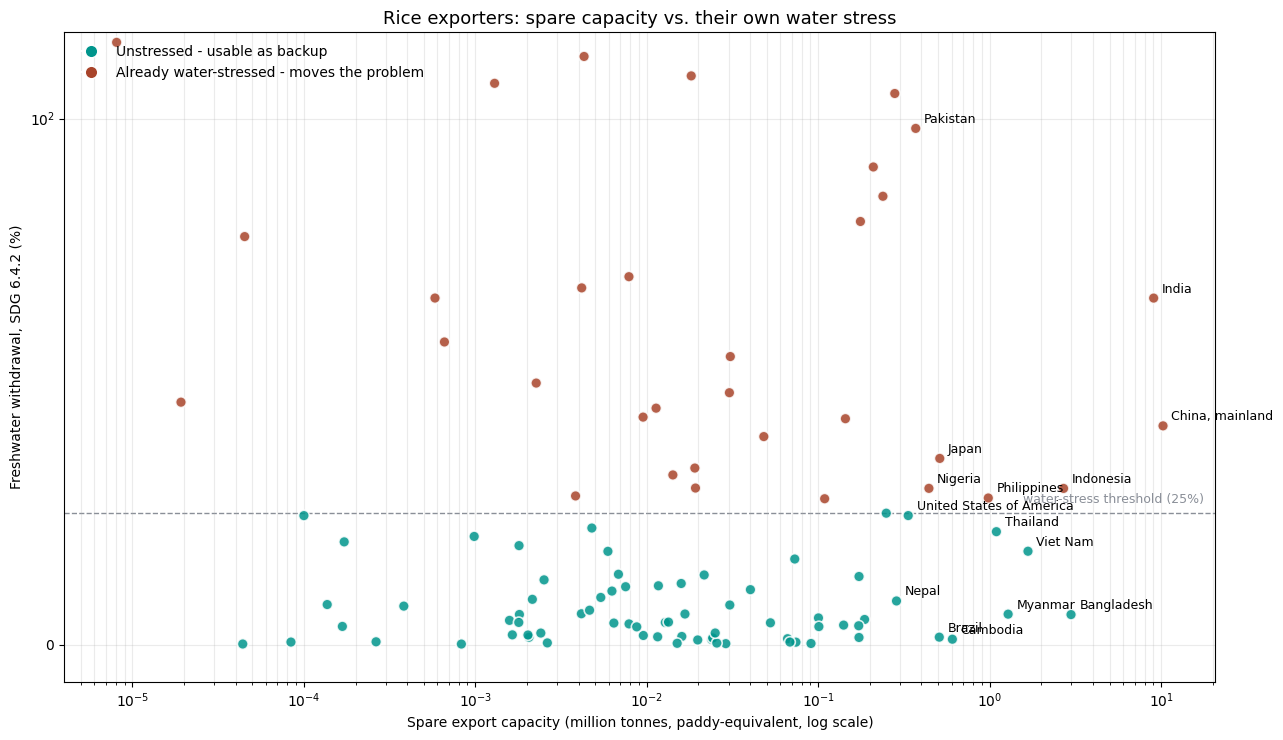

In [39]:
# Where the world's rice capacity sits relative to its water stress. The bottom-right quadrant is
# the one that matters: big headroom, low stress. If it is thin, resilience advice has nowhere to go.
plot_df = supplier_capacity[(supplier_capacity['total_headroom_t'] > 0)
                            & (supplier_capacity['water_stress_pct'].notna())].copy()

fig, ax = plt.subplots(figsize=(13, 7.5))
colors = np.where(plot_df['is_stressed'], C_SIGNAL, C_TEAL)
ax.scatter(plot_df['total_headroom_t'] / 1e6, plot_df['water_stress_pct'],
           s=60, c=colors, alpha=0.85, edgecolors='white', linewidths=1.2, zorder=3)

# Headroom spans several orders of magnitude (a few huge exporters vs. many small ones) -- on a
# linear axis that pins almost every country into a sliver near zero. Log-x spreads them back out.
ax.set_xscale('log')

ax.axhline(CONFIG['stress_threshold_pct'], linestyle='--', color=C_GREY, linewidth=1, zorder=1)
ax.text(0.99, CONFIG['stress_threshold_pct'] + 2,
        f"water-stress threshold ({CONFIG['stress_threshold_pct']}%)",
        transform=ax.get_yaxis_transform(), ha='right', fontsize=9, color=C_GREY)

top_labelled = plot_df.sort_values('total_headroom_t', ascending=False).head(15)
for _, r in top_labelled.iterrows():
    ax.annotate(r['Area'], (r['total_headroom_t'] / 1e6, r['water_stress_pct']),
                xytext=(6, 4), textcoords='offset points', fontsize=9)

ax.set_xlabel('Spare export capacity (million tonnes, paddy-equivalent, log scale)')
ax.set_ylabel('Freshwater withdrawal, SDG 6.4.2 (%)')
ax.set_title('Rice exporters: spare capacity vs. their own water stress', fontsize=13)
ax.set_yscale('symlog', linthresh=100)
ax.grid(True, which='both', alpha=0.25, zorder=0)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_TEAL, markersize=9,
           label='Unstressed - usable as backup'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_SIGNAL, markersize=9,
           label='Already water-stressed - moves the problem'),
], loc='upper left', fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/backup_capacity_vs_stress.png', dpi=150)
plt.show()

### Building blocks used by the spotlight below

`alternatives` (ASR per importer) and the `scale_up_plan` machinery are computed here, ahead of their own sections, purely because the Afghanistan spotlight in Section 3 needs both before the full-world ranking (Section 4) and scale-up tables (Section 5) are revealed. Nothing here changes what they compute -- Sections 4 and 5 build on these exact same objects.

`scale_up_plan` returns two independent plans, not one: a **primary** plan (the nearest-ranked candidates) and a **secondary/backup** plan (`backup_*` fields) built from whoever is left in the same ranked pool after the primary suppliers are set aside -- i.e. "if every primary supplier fell through, who else could still close this same gap." The secondary plan is a full Plan B sized to the same gap, not extra margin stacked on top of the primary one.

**Units: `alternatives`' tonnage columns (and everything derived from them, including `gap_t`) are annual averages, not the 25-year cumulative totals in `dependency_ws`.** `dependency_ws`/`flows` (Section 3) sum FAOSTAT's Detailed Trade Matrix over the full 2000-2024 pull -- fine for a ratio like `dependency_pct`, where the 25-year window cancels out, but not for an absolute tonnage compared against `total_headroom_t` (the capacity section above), which is already a recent-year rate. `summarize_alternatives` below divides by the number of years in the pull (25) before anything downstream uses it, matching the same "25-year total / 25" annualization convention used consistently across this analysis -- so `gap_t` and `total_headroom_t` are both t/year and are safe to compare directly in `close_gap`.

In [40]:
def rank_candidates(importer, candidates, dependency_ws):
    """Candidate suppliers for one importer, ranked by whether a trade relationship already
    exists first, then by water stress (least stressed first), then by size. `candidates` is
    already filtered to CONFIG['backup_requires_tier'] (No stress/Low stress) before it ever
    reaches this function, so every row here already clears that water-stress bar -- this
    function only decides ORDER among suppliers that already qualify, it does not re-filter."""
    existing = set(dependency_ws.loc[dependency_ws['Partner Countries'] == importer,
                                     'Reporter Countries'])
    c = candidates.copy()
    c['already_supplies'] = c['Area'].isin(existing)
    return c.sort_values(['already_supplies', 'water_stress_pct', 'total_headroom_t'],
                         ascending=[False, True, False]).reset_index(drop=True)


def close_gap(gap_t, ranked_candidates, capacity_col='total_headroom_t'):
    """Walk down the ranked candidates allocating capacity until the gap is filled or they run out.
    Returns (filled_t, allocations) where allocations is a list of (supplier, tonnes, is_new).
    Every row it visits before stopping ends up in `allocations` (capacity is always > 0 for a
    candidate, by construction of the candidate pool), so `allocations` always corresponds to an
    exact PREFIX of `ranked_candidates` -- callers rely on this to slice off a used prefix and
    build a backup layer from what's left (see scale_up_plan's `backup_*` fields)."""
    filled, allocations = 0.0, []
    for _, row in ranked_candidates.iterrows():
        remaining = gap_t - filled
        if remaining <= 1e-6:
            break
        take = min(remaining, float(row[capacity_col]))
        if take > 0:
            filled += take
            allocations.append((row['Area'], take, not bool(row['already_supplies'])))
    return filled, allocations


def scale_up_plan(importer, shock_pct, candidates, dependency_ws, alternatives):
    """What it would take to replace `shock_pct` of an importer's stressed supply -- as a PRIMARY
    plan (the nearest-ranked suppliers), and as a SECONDARY/backup plan (what's left in the same
    ranked pool if every primary supplier turned out to be unavailable). The secondary plan is
    built by continuing down the exact same ranked list from where the primary allocation left
    off, and sizing it to close the SAME gap again -- it is not extra margin on top of the primary
    plan, it is an independent Plan B that assumes Plan A fell through entirely."""
    row = alternatives[alternatives['importer'] == importer]
    if row.empty:
        return None
    gap = float(row['stressed_t'].iloc[0]) * shock_pct
    ranked = rank_candidates(importer, candidates, dependency_ws)

    filled, allocations = close_gap(gap, ranked)
    backup_pool = ranked.iloc[len(allocations):].reset_index(drop=True)
    backup_filled, backup_allocations = close_gap(gap, backup_pool)

    return {
        'importer': importer,
        'shock_pct': int(shock_pct * 100),
        'gap_t': gap,
        'filled_t': filled,
        'closed_pct': filled / gap * 100 if gap > 0 else np.nan,
        'residual_t': max(0.0, gap - filled),
        'n_suppliers_needed': len(allocations),
        'n_new_relationships': sum(1 for _, _, is_new in allocations if is_new),
        'allocations': allocations,
        'backup_filled_t': backup_filled,
        'backup_closed_pct': backup_filled / gap * 100 if gap > 0 else np.nan,
        'backup_residual_t': max(0.0, gap - backup_filled),
        'n_backup_suppliers_needed': len(backup_allocations),
        'n_backup_new_relationships': sum(1 for _, _, is_new in backup_allocations if is_new),
        'backup_allocations': backup_allocations,
    }

In [41]:
# dependency_ws's export_qty_t is the 2000-2024 CUMULATIVE sum from Section 3. Divide by the
# number of years in that pull to get an annual average -- the same "25-year total / 25"
# annualization convention used throughout this analysis -- before it becomes an absolute tonnage anywhere
# downstream (gap_t in scale_up_plan, MIN_VOLUME_T below). Percentages and the ASR are ratios of
# these same annualized numbers, so they come out numerically identical either way.
N_YEARS = 2024 - 2000 + 1

def summarize_alternatives(g):
    total = g['export_qty_t'].sum() / N_YEARS
    stressed = g.loc[g['is_stressed'], 'export_qty_t'].sum() / N_YEARS
    no_stress = g.loc[g['water_stress_tier'] == 'No stress', 'export_qty_t'].sum() / N_YEARS
    low_stress = g.loc[g['water_stress_tier'] == 'Low stress', 'export_qty_t'].sum() / N_YEARS
    nodata = g.loc[g['water_stress_tier'] == 'No data', 'export_qty_t'].sum() / N_YEARS
    # "Unstressed" for the ASR = anything BELOW the project's own water-stress threshold
    # (stress_threshold_pct, 25%) -- i.e. No stress + Low stress, the complement of is_stressed.
    # This is fixed to the 25% threshold on purpose, independent of CONFIG['backup_requires_tier']
    # (used in Section 2/5/6 for the scale-up candidate pool): this section measures an importer's
    # CURRENT exposure, which shouldn't silently change if that separate recommendation knob is
    # ever narrowed back to just No stress.
    unstressed = no_stress + low_stress
    return pd.Series({
        'total_from_reporters_t': total,
        'n_suppliers': len(g),
        'stressed_t': stressed,
        'unstressed_t': unstressed,
        'no_stress_t': no_stress,
        'low_stress_t': low_stress,
        'stressed_pct': stressed / total * 100 if total else np.nan,
        'unstressed_pct': unstressed / total * 100 if total else np.nan,
        'no_stress_pct': no_stress / total * 100 if total else np.nan,
        'low_stress_pct': low_stress / total * 100 if total else np.nan,
        'nodata_pct': nodata / total * 100 if total else np.nan,
        'asr': (unstressed / stressed) if stressed > 0 else np.inf,
    })

alternatives = (dependency_ws.groupby('Partner Countries')
                .apply(summarize_alternatives, include_groups=False)
                .reset_index().rename(columns={'Partner Countries': 'importer'}))

alternatives['asr_class'] = pd.cut(
    alternatives['asr'], bins=CONFIG['asr_bins'], labels=CONFIG['asr_labels'], right=False)

# pd.cut leaves an INFINITE ratio unclassified (inf < inf is False), but an infinite ASR means the
# importer buys from no water-stressed supplier at all -- the safest case there is, not a blank.
alternatives.loc[np.isinf(alternatives['asr']), 'asr_class'] = CONFIG['asr_labels'][-1]
alternatives['n_suppliers'] = alternatives['n_suppliers'].astype(int)

# An ASR built mostly on suppliers with no SDG 6.4.2 reading is not a finding, it is a data gap
# wearing one. Flag those rather than letting them rank as if they were measured.
alternatives['asr_reliable'] = alternatives['nodata_pct'] < 25
alternatives = alternatives.sort_values('asr').reset_index(drop=True)

In [42]:
# Shock size used everywhere below: scale-up plans, the pooled allocation, the headline chart.
SHOCK = CONFIG['shock_pct_headline']

## Section 8.3: Afghanistan, a worked example

Before looking at the world, look at the country that motivated this whole notebook. Earlier in this notebook (Alternative Suppliers section), Afghanistan buys 98.5% of its rice from Pakistan alone -- a supplier already at 98.12% freshwater withdrawal -- and that section's `diversify=True` path claims the gap always closes to ~0%, because it assumes unconstrained headroom anywhere. Here is what actually happens once that assumption is replaced with measured capacity and a real water-stress floor on who counts as a backup supplier.

(`FEATURED` is hardcoded to `'Afghanistan'` here rather than picked dynamically, so it can't silently point at a different country if the underlying data changes.)

In [43]:
FEATURED = 'Afghanistan'

row = alternatives[alternatives['importer'] == FEATURED].iloc[0]
plan = scale_up_plan(FEATURED, SHOCK, candidates, dependency_ws, alternatives)

afg_pk_dependency = float(dependency_ws[(dependency_ws['Partner Countries'] == FEATURED)
                                        & (dependency_ws['Reporter Countries'] == 'Pakistan')
                                        ]['dependency_pct'].iloc[0])

print(f'=== {FEATURED} ===')
print(f"  Dependency on Pakistan specifically: {afg_pk_dependency:.1f}%")
print(f"  Suppliers: {int(row['n_suppliers'])}   "
      f"From stressed suppliers: {row['stressed_pct']:.1f}%   "
      f"From unstressed: {row['unstressed_pct']:.2f}%")
print(f"  Alternative Supply Ratio: {row['asr']:.3f}  ({row['asr_class']})")
print(f"\n  At a {plan['shock_pct']}% cut to its stressed suppliers it needs "
      f"{plan['gap_t']:,.0f} t/year replaced.")

print(f"\n  PRIMARY plan: candidates can supply {plan['filled_t']:,.0f} t/year "
      f"({plan['closed_pct']:.1f}% of the gap), "
      f"leaving {plan['residual_t']:,.0f} t/year unmet.")
print(f"  It would take {plan['n_suppliers_needed']} suppliers, of which "
      f"{plan['n_new_relationships']} are trade relationships that do not exist today.")
print('  Ranked by tonnes supplied (descending):')
for supplier, tonnes, is_new in sorted(plan['allocations'], key=lambda a: a[1], reverse=True):
    tag = 'NEW relationship' if is_new else 'existing supplier'
    print(f'    {supplier:<32} {tonnes:>14,.0f} t/year   ({tag})')

print(f"\n  SECONDARY plan (Plan B -- if every primary supplier above were unavailable):")
print(f"  the next-ranked candidates could supply {plan['backup_filled_t']:,.0f} t/year "
      f"({plan['backup_closed_pct']:.1f}% of the same gap), "
      f"leaving {plan['backup_residual_t']:,.0f} t/year unmet.")
print(f"  It would take {plan['n_backup_suppliers_needed']} suppliers, of which "
      f"{plan['n_backup_new_relationships']} are trade relationships that do not exist today.")
print('  Ranked by tonnes supplied (descending):')
for supplier, tonnes, is_new in sorted(plan['backup_allocations'], key=lambda a: a[1], reverse=True):
    tag = 'NEW relationship' if is_new else 'existing supplier'
    print(f'    {supplier:<32} {tonnes:>14,.0f} t/year   ({tag})')

=== Afghanistan ===
  Dependency on Pakistan specifically: 98.5%
  Suppliers: 10   From stressed suppliers: 99.4%   From unstressed: 0.58%
  Alternative Supply Ratio: 0.006  (No real alternative)

  At a 20% cut to its stressed suppliers it needs 37,691 t/year replaced.

  PRIMARY plan: candidates can supply 37,691 t/year (100.0% of the gap), leaving 0 t/year unmet.
  It would take 1 suppliers, of which 0 are trade relationships that do not exist today.
  Ranked by tonnes supplied (descending):
    Russian Federation                       37,691 t/year   (existing supplier)

  SECONDARY plan (Plan B -- if every primary supplier above were unavailable):
  the next-ranked candidates could supply 37,691 t/year (100.0% of the same gap), leaving 0 t/year unmet.
  It would take 1 suppliers, of which 0 are trade relationships that do not exist today.
  Ranked by tonnes supplied (descending):
    Thailand                                 37,691 t/year   (existing supplier)


## Section 8.4: which importers have zero real alternative supply
(built on `dependency_ws` from the Trade Matrix / Water Exposure sections above; answers question 1)

**Is Afghanistan a one-off, or does this generalize?** The Alternative Supply Ratio below scores every importer in the dataset the exact same way just used for Afghanistan in Section 3.

**Alternative Supply Ratio (ASR)** = unstressed import volume / stressed import volume, per importer.
`stressed` and `unstressed` split on the *same* UN-Water threshold used everywhere else in this
notebook (`stress_threshold_pct`, 25% freshwater withdrawal): `stressed` = Medium/High/Critical
tier suppliers, `unstressed` = No-stress + Low-stress tier suppliers. `No data` volume is excluded
from both sides, so a country whose suppliers simply haven't reported SDG 6.4.2 is never scored as
though it were safe.

- **ASR 0.00-0.05** - *No real alternative.* For every 100 t bought from a water-stressed supplier,
  under 5 t comes from a supplier below the threshold. There is no relationship to scale up in a
  hurry.
- **0.05-0.25** - *Thin.*  **0.25-1.0** - *Partial.*  **>= 1.0** - *Adequate.*

**This threshold now matches Section 2/5/6's `backup_requires_tier`.** Both this section's ASR and
the scale-up candidate pool treat No-stress + Low-stress suppliers as real, usable supply -- a
deliberate modeling choice that it's OK to route export volume to a country at 10-25% withdrawal, not just under 10%.
(Earlier versions of this notebook kept the candidate pool stricter than the ASR; that gap is now
closed. To go back to the stricter, measured-only-safe answer for the candidate pool, set
`CONFIG['backup_requires_tier']` back to `['No stress']`.) `no_stress_pct` and `low_stress_pct` are
still reported separately below so the breakdown within `unstressed_pct` stays visible, and the
distortion this fixed is worth remembering: importers buying ~95% of their rice from a
mildly-stressed supplier (Brunei, Cambodia, Ecuador) used to land in the same "No real alternative"
bucket as importers buying almost entirely from Critical-stress suppliers, purely because neither
cleared the stricter 10% cut.

In [44]:
print(alternatives['asr_class'].value_counts().reindex(CONFIG['asr_labels']).to_string())
print(f"\nImporters whose ASR rests on >25% 'No data' volume (excluded from the chart below): "
      f"{(~alternatives['asr_reliable']).sum()}")
print(f"\nImporters with NO real alternative supply: "
      f"{(alternatives['asr_class'] == 'No real alternative').sum()} of {len(alternatives)}")

# Sanity check on the redefinition above: an importer buying mostly Low-stress supply should no
# longer land in "No real alternative" just because none of its suppliers clear the strict
# No-stress bar. If this count isn't near zero, a tier-strictness artifact still remains.
no_alt = alternatives[alternatives['asr_class'] == 'No real alternative']
still_mislabeled = no_alt[no_alt['stressed_pct'] < CONFIG['stress_threshold_pct']]
print(f"  of which still look mislabeled by tier strictness (stressed_pct < "
      f"{CONFIG['stress_threshold_pct']}% yet still 'No real alternative'): {len(still_mislabeled)}")
print(f"  of which genuinely buy mostly from water-stressed suppliers (stressed_pct >= "
      f"{CONFIG['stress_threshold_pct']}%): {len(no_alt) - len(still_mislabeled)}")

print('\nLowest 20 by Alternative Supply Ratio:')
print(alternatives.head(20)[['importer', 'total_from_reporters_t', 'n_suppliers', 'stressed_pct',
                             'no_stress_pct', 'low_stress_pct', 'unstressed_pct', 'nodata_pct',
                             'asr', 'asr_class']]
      .to_string(index=False))

asr_class
No real alternative     15
Thin                    35
Partial                 42
Adequate               107

Importers whose ASR rests on >25% 'No data' volume (excluded from the chart below): 0

Importers with NO real alternative supply: 15 of 199
  of which still look mislabeled by tier strictness (stressed_pct < 25% yet still 'No real alternative'): 0
  of which genuinely buy mostly from water-stressed suppliers (stressed_pct >= 25%): 15

Lowest 20 by Alternative Supply Ratio:
              importer  total_from_reporters_t  n_suppliers  stressed_pct  no_stress_pct  low_stress_pct  unstressed_pct  nodata_pct  asr           asr_class
               Lesotho                 2013.33            4         99.84           0.00            0.16            0.16        0.00 0.00 No real alternative
            Seychelles                 5855.81            9         99.72           0.00            0.28            0.28        0.00 0.00 No real alternative
                Bhutan         

105 importers above 20,000 t/year with a reliable water-stress picture


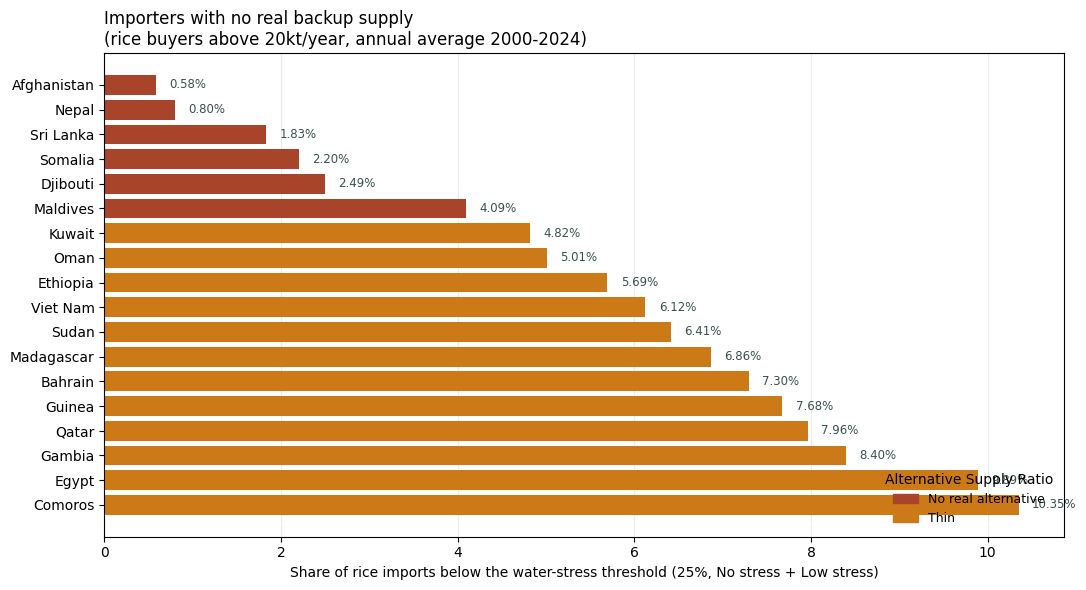

In [45]:
# Only countries buying a meaningful volume -- a tiny importer with one supplier is arithmetically
# extreme but not a food-security story. alternatives' tonnage columns are annual averages (see
# "Building blocks" above), so this is rescaled from the old 500,000 t CUMULATIVE (2000-2024)
# threshold to 500,000 / 25 years, keeping the same effective bar.
MIN_VOLUME_T = 20_000
ranked = alternatives[(alternatives['total_from_reporters_t'] >= MIN_VOLUME_T)
                      & (alternatives['asr_reliable'])].copy()
print(f'{len(ranked)} importers above {MIN_VOLUME_T:,} t/year with a reliable water-stress picture')
top_at_risk = ranked.head(18)

class_color = {'No real alternative': C_SIGNAL, 'Thin': C_OCHRE,
               'Partial': C_INDIGO, 'Adequate': C_TEAL}

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_at_risk['importer'][::-1],
               top_at_risk['unstressed_pct'][::-1],
               color=[class_color.get(c, C_GREY) for c in top_at_risk['asr_class'][::-1]])
for bar, val in zip(bars, top_at_risk['unstressed_pct'][::-1]):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', fontsize=8.5, color='#38504e')

ax.set_xlabel(f"Share of rice imports below the water-stress threshold "
              f"({CONFIG['stress_threshold_pct']}%, No stress + Low stress)")
ax.set_title(f'Importers with no real backup supply\n(rice buyers above '
             f'{MIN_VOLUME_T/1e3:.0f}kt/year, annual average 2000-2024)', loc='left')
ax.grid(True, axis='x', alpha=0.25)
ax.set_axisbelow(True)

ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=class_color[l])
                   for l in CONFIG['asr_labels'] if l in set(top_at_risk['asr_class'].dropna())],
          labels=[l for l in CONFIG['asr_labels'] if l in set(top_at_risk['asr_class'].dropna())],
          loc='lower right', fontsize=9, frameon=False, title='Alternative Supply Ratio')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/backup_gap_alternative_supply_ratio.png', dpi=150)
plt.show()

## Section 9 [Scale-Up Path] : who would have to scale up, and by how much
(generalises `alt_suppliers` from the Alternative Suppliers section above; answers question 2)

**Why the Water Bill's `alt_suppliers` ranking couldn't just be reused.** That section ranks an
importer's *existing* suppliers only (`supplier_mix`, built from that importer's own bilateral
flows) by water-stress tier then current import share, and hands the order to
`simulate_shock(diversify=True)`, which reallocates the lost volume across them assuming
**unconstrained headroom** -- exactly the assumption this notebook exists to remove (see the
intro). Two changes were needed versus that approach:

1. **Candidates are not limited to suppliers the importer already buys from.** The Water Bill's
   `supplier_mix` is empty or nearly so for exactly the countries Section 4 flags as having "No
   real alternative" - there is nothing there to rank. Question 2 asks who would *need to* scale
   up, so the pool here is every unstressed exporter with headroom worldwide, existing customer or
   not. Existing relationships are still preferred first in `rank_candidates` below, and the number
   of brand-new relationships a plan would require is reported as its own column - that is a real
   cost, not a free variable.
2. **Each candidate can only give what it has.** The Water Bill's ranking only sets an order; the
   volume math elsewhere assumes every alternative can absorb whatever is asked of it, which is why
   its diversified gap always closes to ~0%, for every country, at every shock size. `close_gap`
   below stops each candidate at its own measured/assumed `total_headroom_t` and reports the
   residual when the pool runs out, instead of always closing the gap.

In [46]:
# Independent view: every importer is scored as though it were the only country diversifying, which
# is how the Water Bill's diversify=True path implicitly treats them. Includes both the primary plan
# and the secondary/backup plan (see scale_up_plan) -- 'allocations' and 'backup_allocations' are
# list-valued, so they're dropped here the same way; use scale_up_plan directly to inspect either.
independent_rows = []
for importer in ranked['importer']:
    plan = scale_up_plan(importer, SHOCK, candidates, dependency_ws, alternatives)
    if plan:
        independent_rows.append({k: v for k, v in plan.items()
                                  if k not in ('allocations', 'backup_allocations')})

independent = pd.DataFrame(independent_rows).sort_values('gap_t', ascending=False)
print(f'Replacing {int(SHOCK*100)}% of a recent year\'s stressed supply, each importer considered on its own:')
print(independent.head(15)[['importer', 'gap_t', 'closed_pct', 'n_suppliers_needed',
                            'n_new_relationships', 'backup_closed_pct',
                            'n_backup_suppliers_needed', 'n_backup_new_relationships']]
      .to_string(index=False))
print(f"\nFully closable on their own (primary plan): "
      f"{(independent['closed_pct'] >= 99.9).sum()}/{len(independent)} importers")
print(f"Fully closable on their own (secondary/backup plan): "
      f"{(independent['backup_closed_pct'] >= 99.9).sum()}/{len(independent)} importers")

Replacing 20% of a recent year's stressed supply, each importer considered on its own:
                                            importer     gap_t  closed_pct  n_suppliers_needed  n_new_relationships  backup_closed_pct  n_backup_suppliers_needed  n_backup_new_relationships
                                        Saudi Arabia 199886.13      100.00                   4                    0             100.00                          1                           0
                          Iran (Islamic Republic of) 139839.05      100.00                   3                    0             100.00                          1                           0
                                United Arab Emirates 133673.56      100.00                   3                    0             100.00                          1                           0
                                          Bangladesh 117770.63      100.00                   2                    0             100.00                   

## Section 9.2 [Scale-Up Path] : what if everyone diversifies at once?


Section 5 gives every importer the whole candidate pool to draw on. In reality the pool is shared:
if a shock hits a major exporter, every one of its buyers reaches for the same alternatives in the
same week. Spare capacity is a **global stock, not a per-country allowance**.

This section allocates that stock **once**, across all importers, most-exposed served first, and
reports what is left over. The gap between Section 5 and Section 6 is the point of the notebook:
advice that works for one country can fail for all of them simultaneously.

*The priority rule - most-exposed first - is a policy choice, not a fact. Change it to largest
volume, or to lowest income, and the winners change. What does not change is the total.*

In [47]:
# Total demand vs total supply, before any allocation. Both are now annual rates (t/year) --
# gap_t was rescaled from a 25-year cumulative sum in "Building blocks" above specifically so this
# comparison is apples-to-apples with total_headroom_t, which was always a recent-year rate.
total_demand = independent['gap_t'].sum()
total_pool = candidates['total_headroom_t'].sum()
print(f'Demand: {total_demand:,.0f} t/year   Candidate pool: {total_pool:,.0f} t/year')
print(f'The unstressed pool covers {total_pool / total_demand * 100:.1f}% of world demand '
      f'at a {int(SHOCK*100)}% shock.\n')

# Allocate once, most-exposed first. `remaining` is consumed as we go.
priority = (alternatives[alternatives['importer'].isin(independent['importer'])]
            .sort_values('stressed_pct', ascending=False))

remaining = candidates.set_index('Area')['total_headroom_t'].astype(float).copy()
pooled_rows = []
for importer in priority['importer']:
    gap = float(independent.loc[independent['importer'] == importer, 'gap_t'].iloc[0])
    live = candidates[candidates['Area'].isin(remaining[remaining > 0].index)].copy()
    live['total_headroom_t'] = live['Area'].map(remaining)
    ranked_live = rank_candidates(importer, live, dependency_ws)
    filled, allocations = close_gap(gap, ranked_live)
    for supplier, tonnes, _ in allocations:
        remaining[supplier] -= tonnes
    pooled_rows.append({'importer': importer, 'gap_t': gap, 'pooled_filled_t': filled,
                        'pooled_closed_pct': filled / gap * 100 if gap > 0 else np.nan,
                        'n_suppliers_needed': len(allocations)})

pooled = pd.DataFrame(pooled_rows)
comparison = (independent[['importer', 'gap_t', 'closed_pct', 'n_new_relationships']]
              .rename(columns={'closed_pct': 'independent_closed_pct'})
              .merge(pooled[['importer', 'pooled_closed_pct']], on='importer'))

print(f"Fully closable alone      : {(comparison['independent_closed_pct'] >= 99.9).sum()}"
      f"/{len(comparison)}")
print(f"Fully closable once shared: {(comparison['pooled_closed_pct'] >= 99.9).sum()}"
      f"/{len(comparison)}")
print(f"Residual unmet demand     : "
      f"{(comparison['gap_t'] * (1 - comparison['pooled_closed_pct'] / 100)).sum():,.0f} t/year")
print(f"Capacity left in the pool : {remaining[remaining > 0].sum():,.0f} t/year\n")
print(comparison.sort_values('gap_t', ascending=False).head(15).to_string(index=False))

Demand: 2,392,152 t/year   Candidate pool: 10,838,866 t/year
The unstressed pool covers 453.1% of world demand at a 20% shock.

Fully closable alone      : 105/105
Fully closable once shared: 105/105
Residual unmet demand     : 0 t/year
Capacity left in the pool : 8,446,713 t/year

                                            importer     gap_t  independent_closed_pct  n_new_relationships  pooled_closed_pct
                                        Saudi Arabia 199886.13                  100.00                    0             100.00
                          Iran (Islamic Republic of) 139839.05                  100.00                    0             100.00
                                United Arab Emirates 133673.56                  100.00                    0             100.00
                                          Bangladesh 117770.63                  100.00                    0             100.00
                                               Benin 117497.39                  10

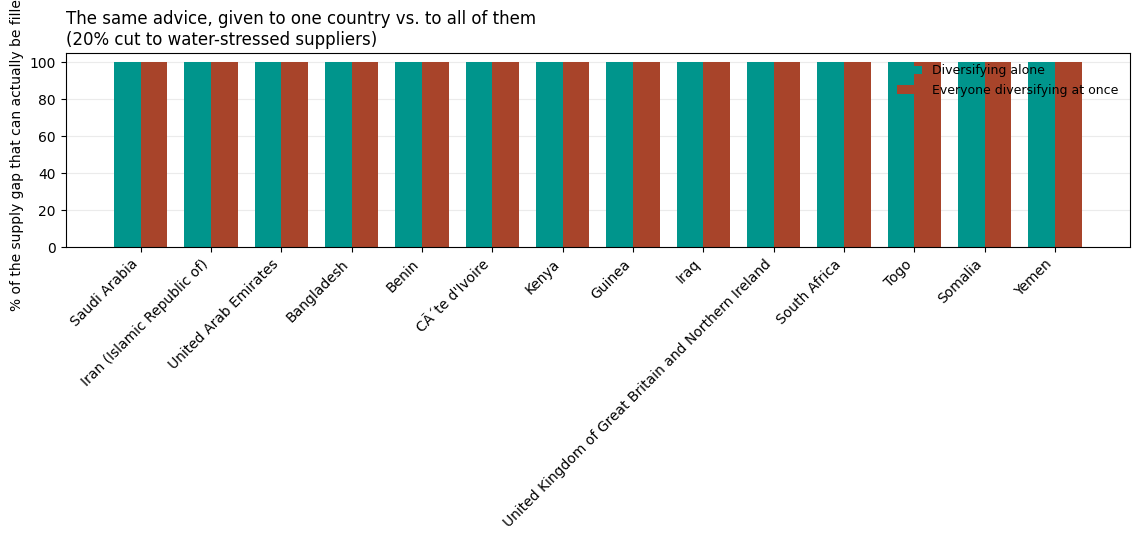

In [48]:
# The headline chart: the same countries, scored alone vs. sharing one pool.
top_n = comparison.sort_values('gap_t', ascending=False).head(14)
x = np.arange(len(top_n))
width = 0.38

fig, ax = plt.subplots(figsize=(11.5, 5.5))
ax.bar(x - width / 2, top_n['independent_closed_pct'], width,
       label='Diversifying alone', color=C_TEAL)
ax.bar(x + width / 2, top_n['pooled_closed_pct'], width,
       label='Everyone diversifying at once', color=C_SIGNAL)

ax.set_xticks(x)
ax.set_xticklabels(top_n['importer'], rotation=45, ha='right')
ax.set_ylabel('% of the supply gap that can actually be filled')
ax.set_ylim(0, 105)
ax.set_title(f'The same advice, given to one country vs. to all of them\n'
             f'({int(SHOCK*100)}% cut to water-stressed suppliers)', loc='left')
ax.legend(frameon=False, fontsize=9)
ax.grid(True, axis='y', alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/backup_gap_alone_vs_pooled.png', dpi=150)
plt.show()

## [Viz][Country Selector] Interactive picker -- pick any importer and see its full profile
Built to explore live rather than read a fixed set of charts: pick any importer from
the dropdown below and see its supplier mix, shock scenario, and alternative suppliers update
together. Reuses `build_shock_profile()` from the breadth section above, nothing new is computed
here that wasn't already computed there.

**One thing to know about this section specifically**: it only works live, inside a running Colab
session. GitHub's notebook viewer only renders whatever was saved as
static output, it doesn't run a kernel, so anyone viewing this on GitHub will see just whichever
country was selected at save time, not a working dropdown. To actually poke at it, open this
notebook directly in Google Colab rather than viewing it on GitHub.


In [49]:
# Uses Plotly for hover/zoom interactivity (pre-installed in Colab) and ipywidgets for the
# dropdown (also pre-installed in Colab) -- no extra pip installs should be needed.
import plotly.graph_objects as go
from ipywidgets import interact, Dropdown
from IPython.display import display

TIER_COLORS = {'No stress': '#2c7fb8', 'Low stress': '#41ab5d', 'Medium stress': '#fec44f',
               'High stress': '#e67e22', 'Critical': '#c0392b', 'No data': '#95a5a6'}

def show_country_profile(importer):
    exp_row = importer_exposure[importer_exposure['importer'] == importer]
    conc_row = concentration[concentration['importer'] == importer]
    profile = build_shock_profile(importer, dependency_ws, pct_reductions=(0.10, 0.20, 0.30))

    if profile is None:
        print(f"No trade-flow data for {importer} in our reporter set -- nothing to show.")
        return

    mix = profile['supplier_mix']
    scenario = profile['scenario']

    print(f"=== {importer} ===")
    print(f"Suppliers in our data: {profile['n_suppliers']}  |  Largest supplier: "
          f"{profile['primary_supplier']} ({profile['primary_supplier_share_pct']:.1f}% of imports)")
    if len(exp_row):
        print(f"Share of rice imports from water-stressed suppliers: "
              f"{exp_row['pct_from_stressed_suppliers'].iloc[0]:.1f}%")
    if len(conc_row):
        print(f"Supplier concentration (HHI): {conc_row['hhi'].iloc[0]:.0f} -- "
              f"{conc_row['concentration_label'].iloc[0]}")

    fig1 = go.Figure(go.Bar(
        x=mix['supplier'], y=mix['share_pct'],
        marker_color=[TIER_COLORS.get(t, '#95a5a6') for t in mix['water_stress_tier']],
        text=mix['water_stress_tier'], hovertemplate='%{x}: %{y:.1f}%<br>%{text}<extra></extra>'))
    fig1.update_layout(title=f'{importer}: rice supplier mix (color = water-stress tier)',
                        yaxis_title='% of imports (from our reporter set)', height=380)
    fig1.show()

    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(x=scenario['reduction_pct'], y=scenario['gap_no_diversification_pct'],
                               mode='lines+markers', name='No diversification'))
    fig2.add_trace(go.Scatter(x=scenario['reduction_pct'], y=scenario['gap_with_diversification_pct'],
                               mode='lines+markers', name='With diversification'))
    fig2.update_layout(title=f"Shock scenario: {importer} sourcing from {profile['primary_supplier']}",
                        xaxis_title=f"{profile['primary_supplier']} export cut (%)",
                        yaxis_title=f"{importer}'s resulting supply gap (%)", height=380)
    fig2.show()

    alt = mix[mix['supplier'] != profile['primary_supplier']].copy()
    if len(alt):
        tier_order = {label: i for i, label in enumerate(CONFIG['water_stress_labels'] + ['No data'])}
        alt['water_headroom_rank'] = alt['water_stress_tier'].map(tier_order)
        alt = alt.sort_values(['water_headroom_rank', 'share_pct'], ascending=[True, False]).reset_index(drop=True)
        alt['diversification_rank'] = alt.index + 1
        print(f"\nAlternative suppliers for {importer} (ranked by water headroom, then existing share):")
        display(alt[['diversification_rank', 'supplier', 'share_pct', 'water_stress_tier']])
    else:
        print(f"\n{importer} has only one supplier in our data -- no alternatives to rank.")


In [54]:
picker_countries = sorted(importer_exposure['importer'].unique())
default_country = 'Afghanistan' if 'Afghanistan' in picker_countries else picker_countries[0]

interact(show_country_profile,
         importer=Dropdown(options=picker_countries, value=default_country, description='Importer:'));


interactive(children=(Dropdown(description='Importer:', options=('Afghanistan', 'Albania', 'Algeria', 'Angola'…

## Limitations & next steps
*(follows the same before/after limitations pattern used throughout this analysis)*

**What's verified:**
- Production and export figures use the conversion-factor logic validated against FAOSTAT's own
  item-code documentation (QCL code 27 for production; TCL codes 28÷0.77 + 31÷0.67 for
  exports, cross-checked against an independent milled-equivalent accumulation method). The Backup
  Gap section reuses these same dataframes directly, rather than rebuilding them.
- The reporter shortlist (Section 2) is computed dynamically from the data, not hardcoded, so it
  stays correct as FAOSTAT revises figures.
- Water-stress values are each country's LATEST available SDG 6.4.2 reading -- never imputed; a
  country with no reading is labeled "No data" and excluded from stressed-supplier percentages
  (and from both sides of the Backup Gap's Alternative Supply Ratio), not silently assumed safe.

**What's estimated or simplified:**
- The shock simulator assumes 1:1 elasticity (a supplier's production cut translates directly and
  fully into an export cut to every buyer) and no price response -- real supply shocks trigger price
  changes and substitution effects this doesn't model.
- The diversification scenario (outside the Backup Gap's capacity-constrained sections) assumes
  unconstrained headroom at alternative suppliers -- in practice, scaling up a secondary supplier
  has its own limits (land, water, logistics) not modeled here.
- Country-name matching between the Trade Matrix and SDGB (Section: Water Exposure) relies on
  FAOSTAT's naming being consistent across domains. The match-report cell prints anything that
  didn't match; if `NAME_ALIASES` is still empty after a real run, that's confirmed, not assumed.
- The water-VOLUME figure now IS computed (Mekonnen & Hoekstra, Report 40, paddy-basis m3/ton x a
  recent 3-year average tonnage), but it rests on a 2000-04 base-period water-footprint INTENSITY
  applied to CURRENT trade volume -- a standard convention in the water-footprint literature, not a
  current-year measurement. It also only covers the 8 countries in `WATER_FOOTPRINT_M3_PER_TON`;
  any other country's water-volume claim is still not computable without adding its own sourced
  entry. Reverse-checking the claimed 4.97 km3 figure for Pakistan against Report 40's OWN 2000-04
  net-virtual-water-export figure for Pakistan (2.92 km3/yr, Table 7) shows the claimed number is
  roughly double that base-period figure -- plausible if Pakistan's rice exports have grown
  meaningfully since 2000-04 (they have), but this notebook's own computed value (from CURRENT
  export tonnage) is the one to trust over a mental reverse-engineering -- see the credibility-check
  table's actual MATCH/MISMATCH verdict once this has been run for real.
- **The Backup Gap's `total_headroom_t` is entirely the divertible share of retained production:**
  `(recent_production_t - recent_export_t) * divertible_share_of_retained` (default 5%). This is a
  policy assumption, not a measurement - it presumes a country would redirect part of its domestic
  crop to export, which has a food-security cost this notebook does not model. Set it to 0.0 and
  headroom goes to zero for every supplier under this definition.
- **Bilateral shares are of the reporter set, not the world.** The Trade Matrix pull only covers
  shortlisted exporters, so an importer buying from a country outside that shortlist has that
  volume invisible here. This understates alternatives for some importers.
- **Capacity is treated as fungible.** A tonne of Thai spare capacity is assumed deliverable to any
  buyer. Freight, contracts, variety preference and import standards all say otherwise.
- **The priority rule in the Scale-Up Path section above** (most-exposed first) determines who
  gets served, not how much exists. Change the rule and individual countries move; the residual
  does not.
- **No price response.** A shortage raises prices, which draws out supply this model cannot see and
  prices out buyers it does not track. Both effects are real and both are missing.